# FAOSTAT food-systems analytics

This notebook walks through the whole project on the FAO statistical database: the SQLite warehouse
built from nine FAOSTAT bulk domains, the 35 analytical questions with their SQL, figures and findings,
the four predictive models, and the interactive dashboard.

* Repository: https://github.com/chidex-coder/faostat-food-systems-analytics
* Live dashboard: https://chidex-coder.github.io/faostat-food-systems-analytics/
* Written findings: `reports/analysis_report.md` · Model card: `models/MODEL_CARD.md`

Run `python run_pipeline.py` first so `data/faostat.db` exists; every cell below reads from that warehouse
and calls the same functions the pipeline runs, so the notebook and the reports cannot disagree.


## 1. Setup

In [1]:
import json, sqlite3, sys
from pathlib import Path

import pandas as pd
import plotly.io as pio
from IPython.display import HTML, IFrame, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import viz                       # registers the shared Plotly theme
from src.analysis import HANDLERS, _sql
from src.config import DB_PATH

pio.renderers.default = "plotly_mimetype+png"   # interactive in Jupyter, PNG on GitHub
pio.defaults.default_width = 1000
pio.defaults.default_height = 520
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

con = sqlite3.connect(DB_PATH)


def answer(slug, show_table=True):
    """Run one question: SQL from sql/questions, the analysis handler, then figure + findings."""
    sql, question = _sql(slug)
    theme, handler = HANDLERS[slug]
    df = pd.read_sql_query(sql, con)
    fig, findings, numbers, *rest = handler(df)
    table = rest[0] if rest else df
    display(fig)
    display(Markdown("\n".join(f"- {f}" for f in findings)))
    if show_table:
        display(table.head(12))
    return table

print(f"warehouse: {DB_PATH.relative_to(ROOT)} · {con.execute('SELECT COUNT(*) FROM observation').fetchone()[0]:,} observations")


warehouse: data/faostat.db · 7,333,827 observations


## 2. The warehouse

Nine domains, one long fact table, conformed dimensions, and a quality gate that runs on every build.

In [2]:
for name in ["observation", "dim_area", "dim_item", "dim_element", "dim_flag", "dim_domain", "dq_check"]:
    n = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    cols = [r[1] for r in con.execute(f"PRAGMA table_info({name})")]
    print(f"{name:12} {n:>10,} rows   {', '.join(cols)}")
print()
print("views:", ", ".join(r[0] for r in con.execute("SELECT name FROM sqlite_master WHERE type='view' ORDER BY name")))


observation   7,333,827 rows   domain, area_code, item_code, element_code, year, year_label, value, flag, note
dim_area            339 rows   area_code, m49_code, area, is_aggregate, iso3, region, subregion, intermediate_region, is_ldc, is_lldc, is_sids
dim_item            714 rows   domain, item_code, item, cpc_code
dim_element          52 rows   domain, element_code, element, unit
dim_flag             39 rows   domain, flag, description
dim_domain            9 rows   domain, name, source_file, source_url, sha256, server_last_modified, catalogue_date_update, downloaded_at, rows_raw, rows_loaded, rows_dropped_missing, rows_dropped_filter, rows_dropped_dupe, notes
dq_check             27 rows   run_at, domain, check_name, status, observed, threshold, detail

views: v_country, v_emissions, v_fertilizer, v_food_security, v_healthy_diet, v_land, v_population, v_price_usd, v_production, v_temperature


In [3]:
domains = pd.read_sql_query("""SELECT domain, name, rows_raw, rows_loaded, rows_dropped_filter, rows_dropped_missing,
                                       rows_dropped_dupe, substr(sha256, 1, 12) AS sha256, catalogue_date_update
                                FROM dim_domain ORDER BY rows_loaded DESC""", con)
display(domains)

dq = pd.read_sql_query("""SELECT check_name, domain, status, observed, threshold, detail
                          FROM dq_check WHERE run_at = (SELECT MAX(run_at) FROM dq_check)""", con)
print(dq.status.value_counts().to_dict())
display(dq[dq.status != "pass"] if (dq.status != "pass").any() else Markdown("All checks pass."))


,domain,name,rows_raw,rows_loaded,rows_dropped_filter,rows_dropped_missing,rows_dropped_dupe,sha256,catalogue_date_update
0,QCL,Production: Crops and livestock products,4209110,4114755,0,94355,0,c5835418c18f,2025-12-31T00:00:00
1,GT,Climate Change: Agrifood systems emissions totals,2500090,1362938,1137152,0,0,d2c47e116553,2025-10-28T00:00:00
2,ET,"Land, Inputs and Sustainability: Temperature c...",590512,568179,0,22333,0,1acf303d3d94,2026-04-01T00:00:00
3,RL,"Land, Inputs and Sustainability: Land Use",421859,421774,0,85,0,f6ccf002c3e8,2026-07-17T00:00:00
4,PP,Prices: Producer Prices,1319563,338803,980760,0,0,0eaff92014d4,2026-01-09T00:00:00
5,RFN,"Land, Inputs and Sustainability: Fertilizers b...",256304,256244,0,60,0,6cf684dd5366,2026-07-30T00:00:00
6,FS,Food Security and Nutrition: Suite of Food Sec...,287735,182339,77184,28212,0,1ccced40d8e2,2026-07-21T00:00:00
7,OA,Population and Employment: Annual population,168405,81901,86504,0,0,e2781a554d4e,2026-03-09T00:00:00
8,CAHD,Cost and Affordability of a Healthy Diet,10320,6894,2610,816,0,299e15188c24,2026-07-21T00:00:00


{'pass': 27}


All checks pass.

### Headline numbers (World)

In [4]:
kpis = pd.read_sql_query("""
WITH w AS (SELECT * FROM v_production WHERE area_code = 5000 AND item_code = '1717' AND year = 2024),
     f AS (SELECT * FROM v_food_security WHERE area_code = 5000 AND year = 2024),
     e AS (SELECT * FROM v_emissions WHERE area_code = 5000 AND year = 2023),
     t AS (SELECT * FROM v_temperature WHERE area_code = 5000 AND year = 2024),
     h AS (SELECT * FROM v_healthy_diet WHERE area_code = 5000 AND year = 2025)
SELECT w.production_t / 1e6 AS cereal_production_mt_2024, w.yield_kg_ha / 1000.0 AS cereal_yield_t_ha_2024,
       f.pou_pct AS undernourishment_pct_2024, f.undernourished_m AS undernourished_million_2024,
       e.agrifood_kt_co2eq / 1e6 AS agrifood_gt_co2eq_2023, t.temp_change_c AS temp_change_c_2024,
       h.unaffordable_pct AS cannot_afford_healthy_diet_pct_2025
FROM w, f, e, t, h""", con)
kpis.T.rename(columns={0: "World"}).round(2)


,World
cereal_production_mt_2024,3133.22
cereal_yield_t_ha_2024,4.21
undernourishment_pct_2024,8.10
undernourished_million_2024,663.30
agrifood_gt_co2eq_2023,16.54
temp_change_c_2024,2.11
cannot_afford_healthy_diet_pct_2025,32.70


## 3. The questions

Each question is a SQL file in `sql/questions/` and a handler in `src/analysis.py`. The SQL is shown before each cell; the cell runs it, renders the figure and prints the generated findings.

### Production

#### Q01. How has world cereal production, harvested area and yield evolved since 1961?

```sql
-- Q01 How has world cereal production, harvested area and yield evolved since 1961?
SELECT year,
       production_t / 1e6      AS production_mt,
       area_harvested_ha / 1e6 AS area_mha,
       yield_kg_ha / 1000.0    AS yield_t_ha
FROM v_production
WHERE area_code = 5000 AND item_code = '1717'
ORDER BY year;
```

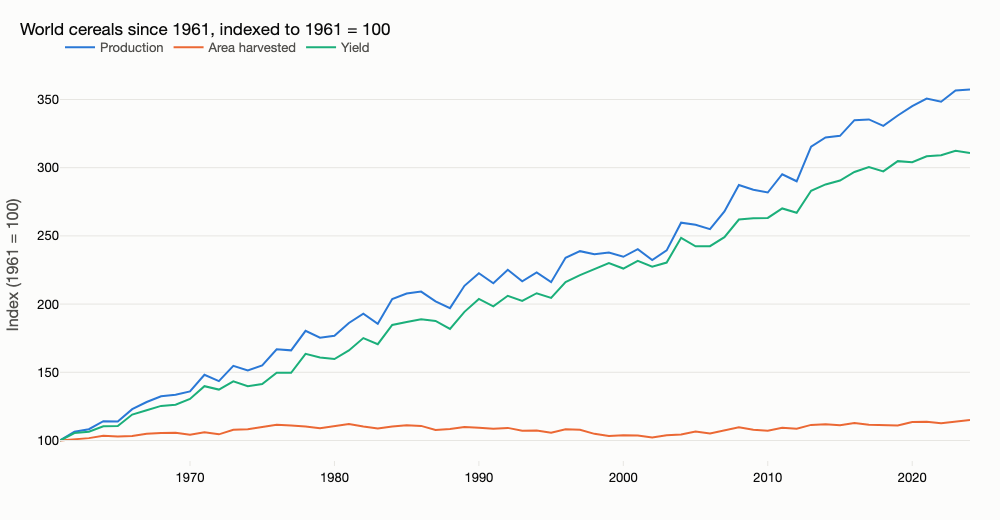

- World cereal production rose from 877 Mt in 1961 to 3,133 Mt in 2024 (3.6x, 2.0 % a year).
- Harvested area grew only 15 % (648 -> 745 Mha); yield rose 211 % (1.35 -> 4.21 t/ha), so intensification, not expansion, fed the growth.

,year,production_mt,area_mha,yield_t_ha
0,1961,876.874515,647.997176,1.3532
1,1962,933.372941,653.839490,1.4275
2,1963,949.345879,659.234457,1.4401
3,1964,1001.214043,670.231853,1.4938
4,1965,998.593005,667.195164,1.4967
5,1966,1078.340172,669.678967,1.6102
6,1967,1124.081315,679.890939,1.6533
7,1968,1160.679018,684.204592,1.6964
8,1969,1170.980071,685.279115,1.7088
9,1970,1192.507676,675.463516,1.7655


In [5]:
global_cereal_production = answer("q01_global_cereal_production")

#### Q02. Which countries produce the most cereals today and what share of the world total is that?

```sql
-- Q02 Which countries produce the most cereals today and what share of the world total is that?
WITH latest AS (SELECT MAX(year) AS y FROM v_production WHERE area_code = 5000 AND item_code = '1717')
SELECT p.area, p.region, p.year,
       p.production_t / 1e6 AS production_mt,
       100.0 * p.production_t / w.production_t AS share_pct
FROM v_production p
JOIN latest ON p.year = latest.y
JOIN v_production w ON w.area_code = 5000 AND w.item_code = '1717' AND w.year = p.year
WHERE p.item_code = '1717' AND p.is_aggregate = 0 AND p.region IS NOT NULL
ORDER BY p.production_t DESC
LIMIT 15;
```

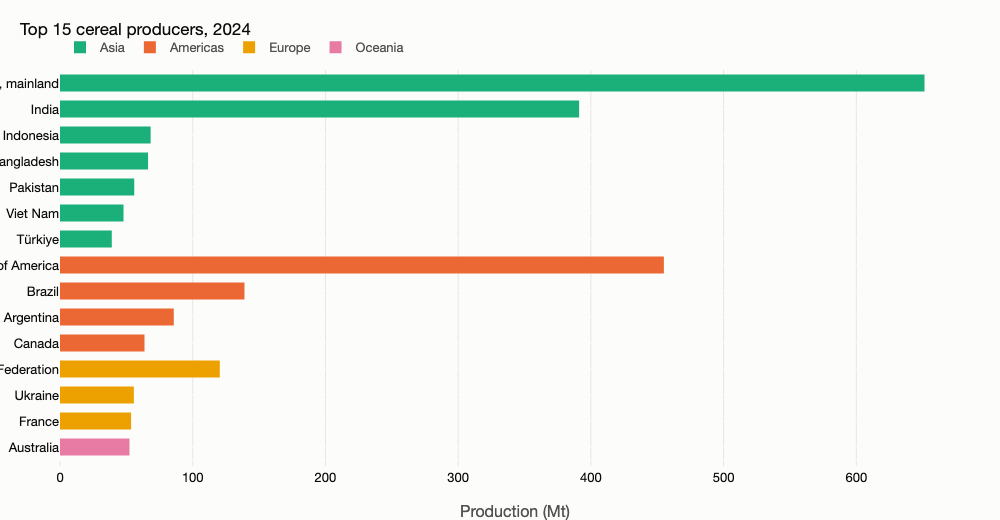

- China, mainland, United States of America, India produce 48 % of world cereals (1,497 Mt of the top-15 total 2,345 Mt).
- The 15 largest producers account for 75 % of global output; Asia contributes the most entries in the list.

,area,region,year,production_mt,share_pct
0,"China, mainland",Asia,2024,651.355743,20.788683
1,United States of America,Americas,2024,454.987916,14.521403
2,India,Asia,2024,391.123858,12.483117
3,Brazil,Americas,2024,138.980899,4.435717
4,Russian Federation,Europe,2024,120.400172,3.842694
5,Argentina,Americas,2024,85.727346,2.736076
6,Indonesia,Asia,2024,68.281639,2.179278
7,Bangladesh,Asia,2024,66.347851,2.117559
8,Canada,Americas,2024,63.660405,2.031787
9,Pakistan,Asia,2024,55.933133,1.785163


In [6]:
top_cereal_producers = answer("q02_top_cereal_producers")

#### Q03. How do wheat, maize and rice yields compare across continents and how fast are they rising?

```sql
-- Q03 How do wheat, maize and rice yields compare across continents and how fast are they rising?
SELECT a.area AS region, i.item, p.year, p.yield_kg_ha / 1000.0 AS yield_t_ha
FROM v_production p
JOIN dim_area a USING (area_code)
JOIN dim_item i ON i.domain = 'QCL' AND i.item_code = p.item_code
WHERE p.area_code IN (5100, 5200, 5300, 5400, 5500)
  AND p.item_code IN ('15', '56', '27')
ORDER BY i.item, a.area, p.year;
```

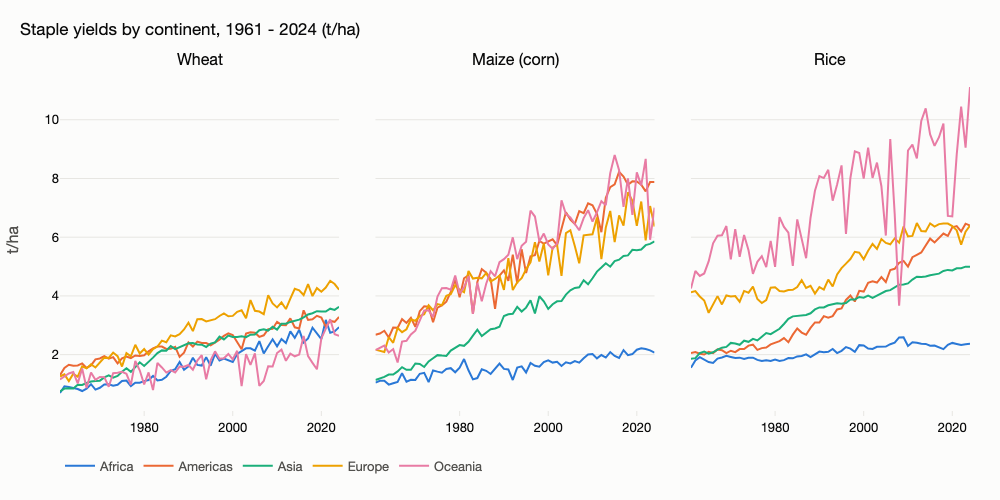

- Wheat: Europe leads at 4.2 t/ha while Oceania trails at 2.6 t/ha - a 1.6x gap in 2024.
- Maize (corn): Americas leads at 7.9 t/ha while Africa trails at 2.1 t/ha - a 3.8x gap in 2024.
- Rice: Oceania leads at 11.1 t/ha while Africa trails at 2.4 t/ha - a 4.7x gap in 2024.
- Since 1961 maize yields multiplied 5.1x in Asia but only 2.0x in Africa.

,region,item,year,yield_t_ha
0,Africa,Maize (corn),1961,1.0444
1,Africa,Maize (corn),1962,1.1112
2,Africa,Maize (corn),1963,1.1094
3,Africa,Maize (corn),1964,0.9796
4,Africa,Maize (corn),1965,1.0272
5,Africa,Maize (corn),1966,1.0729
6,Africa,Maize (corn),1967,1.3685
7,Africa,Maize (corn),1968,1.0753
8,Africa,Maize (corn),1969,1.1412
9,Africa,Maize (corn),1970,1.1382


In [7]:
staple_yields_by_region = answer("q03_staple_yields_by_region")

#### Q04. Where is the maize yield gap largest? (2022-2024 average vs the top-decile yield)

```sql
-- Q04 Where is the maize yield gap largest? (2022-2024 average vs the top-decile yield)
SELECT area, region, subregion,
       AVG(yield_kg_ha) / 1000.0 AS yield_t_ha,
       AVG(area_harvested_ha)    AS area_ha,
       AVG(production_t)         AS production_t
FROM v_production
WHERE item_code = '56' AND is_aggregate = 0 AND region IS NOT NULL
  AND year BETWEEN 2022 AND 2024
GROUP BY area_code
HAVING COUNT(*) = 3 AND AVG(area_harvested_ha) >= 100000;
```

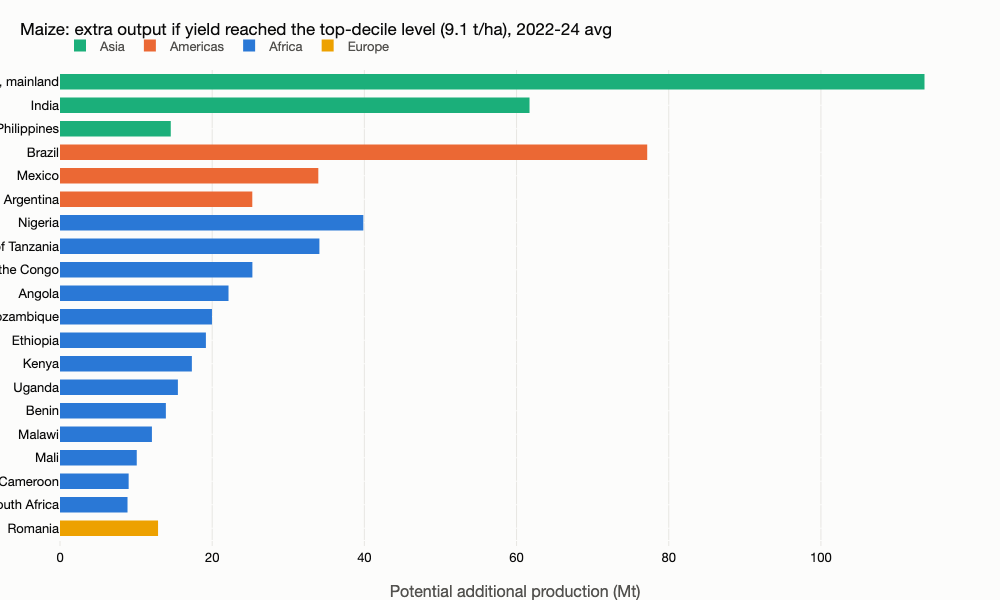

- The top-decile maize yield among countries harvesting >= 100 kha is 9.1 t/ha; the median country reaches 3.5 t/ha.
- Closing the gap in just China, mainland, Brazil, India would add 252 Mt - the 20 largest gaps together represent 586 Mt of latent production.
- By region the median yield is Africa 1.7 t/ha, Americas 4.0 t/ha, Asia 5.5 t/ha, Europe 7.0 t/ha.

,area,region,subregion,yield_t_ha,area_ha,production_t,gap_t_ha,gap_pct,potential_extra_mt
14,"China, mainland",Asia,Eastern Asia,6.520000,4.400987e+07,2.869884e+08,2.581493,28.363404,113.611177
6,Brazil,Americas,Latin America and the Caribbean,5.516000,2.152281e+07,1.188817e+08,3.585493,39.394561,77.169888
33,India,Asia,Southern Asia,3.422233,1.086501e+07,3.720331e+07,5.679260,62.399211,61.705234
51,Nigeria,Africa,Sub-Saharan Africa,2.067167,5.666667e+06,1.172197e+07,7.034327,77.287610,39.861184
66,United Republic of Tanzania,Africa,Sub-Saharan Africa,1.766000,4.647227e+06,8.210650e+06,7.335493,80.596591,34.089703
46,Mexico,Americas,Latin America and the Caribbean,3.961333,6.604429e+06,2.614322e+07,5.140160,56.476007,33.947823
78,Democratic Republic of the Congo,Africa,Sub-Saharan Africa,0.769700,3.034594e+06,2.335675e+06,8.331793,91.543146,25.283613
2,Argentina,Americas,Latin America and the Caribbean,6.141033,8.536598e+06,5.264704e+07,2.960460,32.527190,25.272257
1,Angola,Africa,Sub-Saharan Africa,1.154800,2.786894e+06,3.219020e+06,7.946693,87.311972,22.146589
48,Mozambique,Africa,Sub-Saharan Africa,0.970433,2.456182e+06,2.275402e+06,8.131060,89.337647,19.971363


In [8]:
maize_yield_gap = answer("q04_maize_yield_gap")

#### Q05. Since 2000, how much of each region's cereal production growth came from yield versus area?

```sql
-- Q05 Since 2000, how much of each region's cereal production growth came from yield versus area?
WITH latest AS (SELECT MAX(year) AS y FROM v_production WHERE area_code = 5000 AND item_code = '1717')
SELECT a.area AS region, p.year, p.production_t, p.area_harvested_ha, p.yield_kg_ha
FROM v_production p JOIN dim_area a USING (area_code), latest
WHERE p.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND p.item_code = '1717'
  AND p.year IN (2000, latest.y)
ORDER BY a.area, p.year;
```

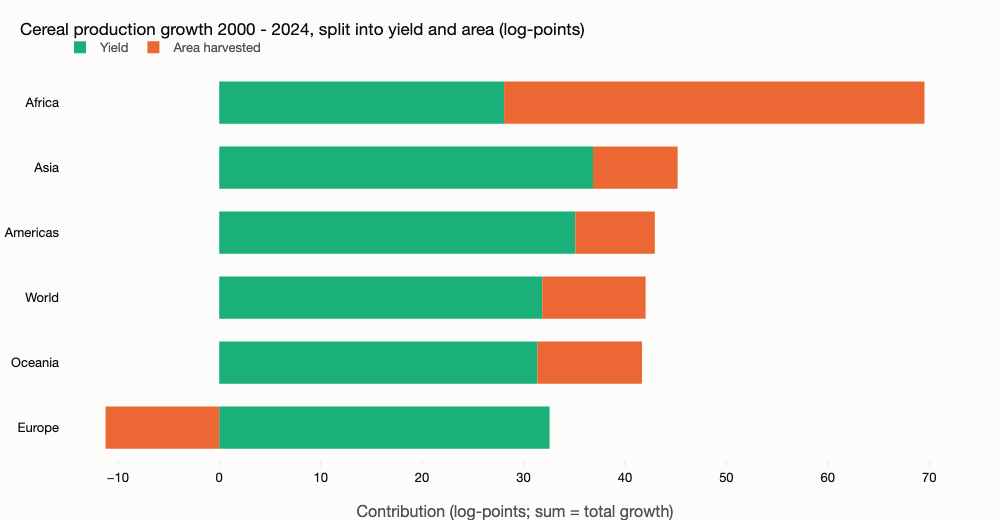

- Europe: production +24 %, of which yield explains 152 % and area -53 %.
- Oceania: production +52 %, of which yield explains 75 % and area 25 %.
- World: production +52 %, of which yield explains 76 % and area 24 %.
- Americas: production +54 %, of which yield explains 82 % and area 18 %.
- Asia: production +57 %, of which yield explains 82 % and area 18 %.
- Africa: production +100 %, of which yield explains 40 % and area 60 %.

,region,growth_pct,area_share,yield_share,area_contrib_pct,yield_contrib_pct,to_year
3,Europe,23.808955,-52.500754,152.493920,-11.212560,32.568051,2024
4,Oceania,51.710447,24.756504,75.244301,10.318599,31.362093,2024
5,World,52.253185,24.255958,75.744139,10.196590,31.840915,2024
1,Americas,53.645303,18.258397,81.741851,7.841553,35.106207,2024
2,Asia,57.131492,18.457766,81.547211,8.341301,36.852229,2024
0,Africa,100.440714,59.607057,40.389249,41.447668,28.084596,2024


In [9]:
growth_decomposition = answer("q05_growth_decomposition")

#### Q06. How has world meat production shifted between poultry, pig, bovine and sheep/goat meat?

```sql
-- Q06 How has world meat production shifted between poultry, pig, bovine and sheep/goat meat?
SELECT i.item, o.year, o.value / 1e6 AS production_mt
FROM observation o JOIN dim_item i ON i.domain = o.domain AND i.item_code = o.item_code
WHERE o.domain = 'QCL' AND o.area_code = 5000 AND o.element_code = 5510
  AND o.item_code IN ('1806', '1808', '1035', '1807')
ORDER BY i.item, o.year;
```

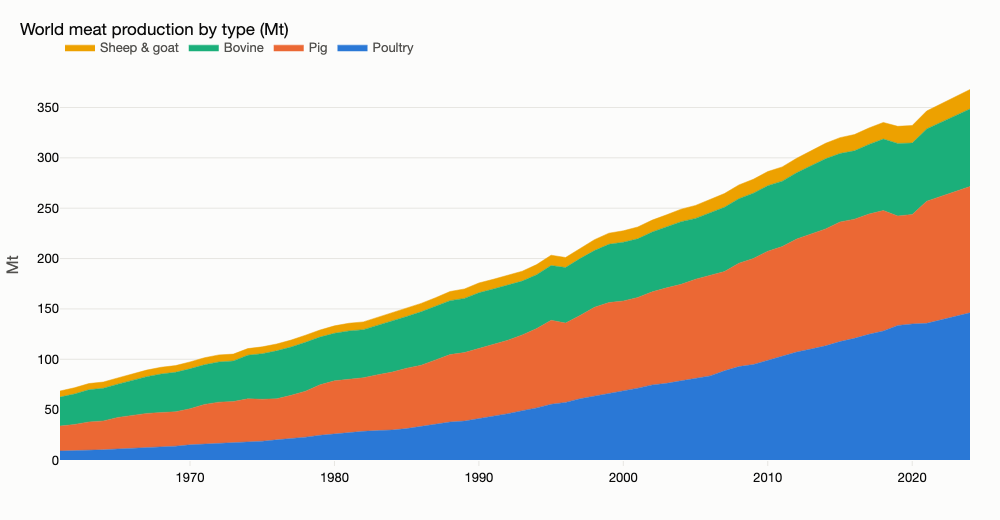

- Total meat output grew from 68 Mt (1961) to 368 Mt (2024).
- Poultry's share rose from 13 % to 40 %; it overtook pig meat in 2016.
- Bovine meat's share fell from 42 % to 21 %.

,item,year,production_mt
0,"Beef and Buffalo Meat, primary",1961,28.753174
1,"Beef and Buffalo Meat, primary",1962,30.305241
2,"Beef and Buffalo Meat, primary",1963,31.973646
3,"Beef and Buffalo Meat, primary",1964,32.434628
4,"Beef and Buffalo Meat, primary",1965,33.038106
5,"Beef and Buffalo Meat, primary",1966,34.751601
6,"Beef and Buffalo Meat, primary",1967,36.494636
7,"Beef and Buffalo Meat, primary",1968,38.225145
8,"Beef and Buffalo Meat, primary",1969,39.208593
9,"Beef and Buffalo Meat, primary",1970,39.658854


In [10]:
global_meat_production = answer("q06_global_meat_production")

#### Q07. Which sizeable cereal producers have the most volatile output (2010-2024)?

```sql
-- Q07 Which sizeable cereal producers have the most volatile output (2010-2024)?
SELECT area, region, year, production_t
FROM v_production
WHERE item_code = '1717' AND is_aggregate = 0 AND region IS NOT NULL AND year BETWEEN 2010 AND 2024;
```

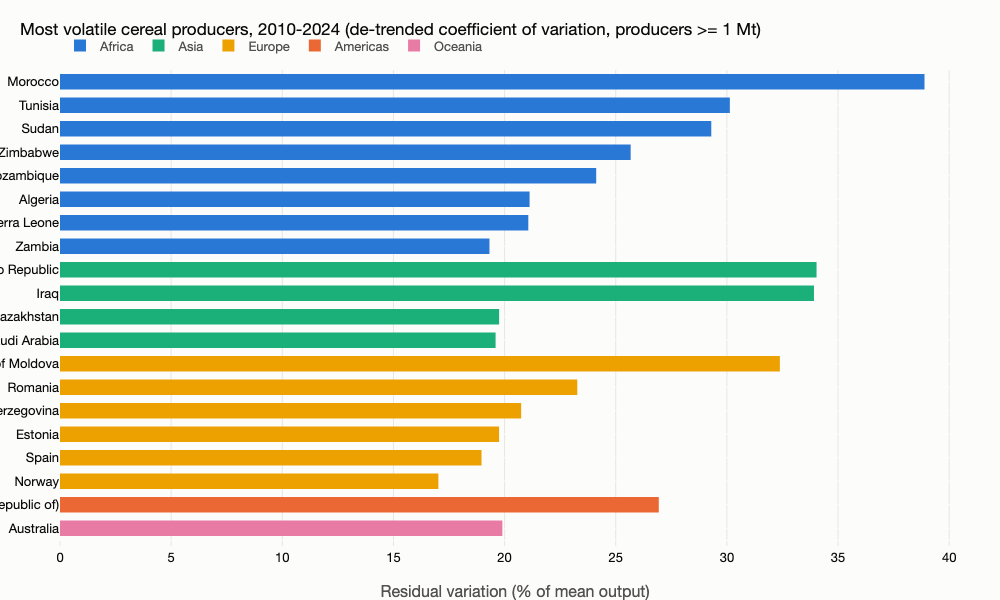

- Morocco has the most volatile cereal output (39 % of its 7.0 Mt mean), followed by Syrian Arab Republic and Iraq.
- 8 of the 20 most volatile producers are African; the median de-trended CV across all 107 producers is 9.9 %.

,area,region,detrended_cv_pct,mean_mt
60,Morocco,Africa,38.888767,7.034052
89,Syrian Arab Republic,Asia,34.032657,3.841155
45,Iraq,Asia,33.916100,5.341333
76,Republic of Moldova,Europe,32.383347,2.674761
93,Tunisia,Africa,30.132781,1.645971
87,Sudan,Africa,29.297439,6.073269
103,Venezuela (Bolivarian Republic of),Americas,26.935816,2.868863
106,Zimbabwe,Africa,25.670879,1.352085
61,Mozambique,Africa,24.120517,2.125106
77,Romania,Europe,23.269613,21.800144


In [11]:
production_volatility = answer("q07_production_volatility")

#### Q34. Which commodities have grown fastest in world production since 2000?

```sql
-- Q34 Which commodities have grown fastest in world production since 2000?
-- Item codes >= 1700 are FAOSTAT commodity groups (Cereals primary, Milk total, ...) and are excluded.
SELECT i.item, o.year, o.value / 1e6 AS production_mt
FROM observation o JOIN dim_item i ON i.domain = o.domain AND i.item_code = o.item_code
WHERE o.domain = 'QCL' AND o.area_code = 5000 AND o.element_code = 5510 AND o.year IN (2000, 2024)
  AND CAST(o.item_code AS INTEGER) < 1700
ORDER BY i.item, o.year;
```

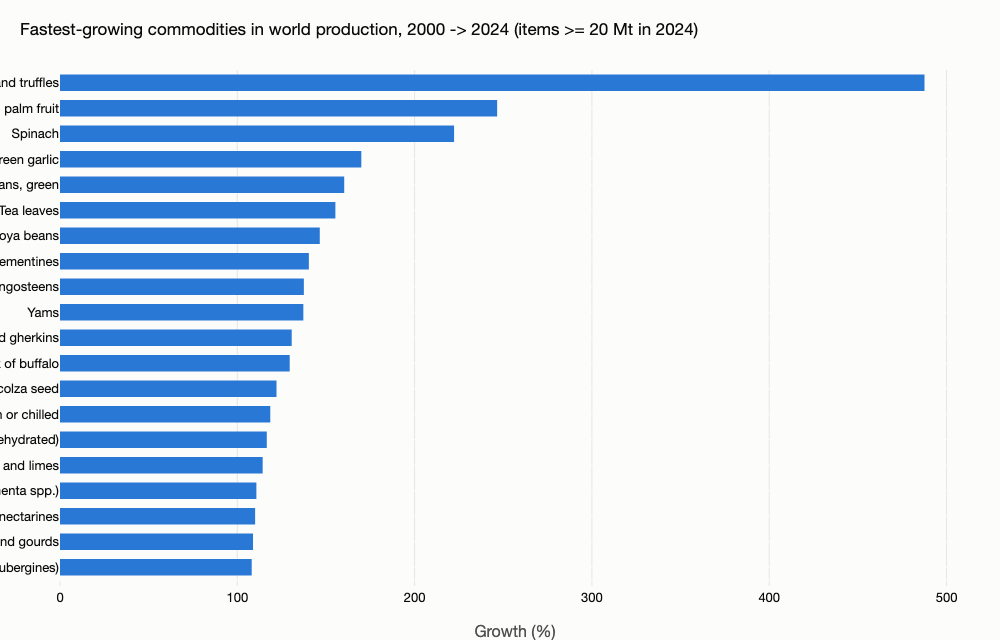

- Fastest growth: Mushrooms and truffles (+488 %), Oil palm fruit (+247 %), Spinach (+222 %).
- Largest absolute additions: Sugar cane +687 Mt, Maize (corn) +626 Mt, Raw milk of cattle +308 Mt, Oil palm fruit +298 Mt, Soya beans +236 Mt.

year,item,2000,2024,growth_pct,added_mt
0,Mushrooms and truffles,8.781003,51.595327,487.578992,42.814325
1,Oil palm fruit,120.816965,418.696914,246.554737,297.879949
2,Spinach,9.531755,30.717391,222.263733,21.185635
3,Green garlic,10.998744,29.690764,169.946867,18.692020
4,"Other beans, green",9.962238,25.931333,160.296253,15.969095
5,Tea leaves,12.818988,32.728931,155.316029,19.909943
6,Soya beans,161.312583,397.671689,146.522423,236.359105
7,"Tangerines, mandarins, clementines",21.600407,51.917893,140.356092,30.317487
8,"Mangoes, guavas and mangosteens",26.190045,62.211835,137.540002,36.021789
9,Yams,38.965399,92.442677,137.242990,53.477279


In [12]:
fastest_growing_commodities = answer("q34_fastest_growing_commodities")

#### Q35. How have global livestock herds (cattle, pigs, sheep, goats, chickens) changed since 1961?

```sql
-- Q35 How have global livestock herds (cattle, pigs, sheep, goats, chickens) changed since 1961?
SELECT i.item, o.year, o.element_code, o.value
FROM observation o JOIN dim_item i ON i.domain = o.domain AND i.item_code = o.item_code
WHERE o.domain = 'QCL' AND o.area_code = 5000 AND o.element_code IN (5111, 5112)
  AND o.item_code IN ('866', '1034', '976', '1016', '1057')
ORDER BY i.item, o.year;
```

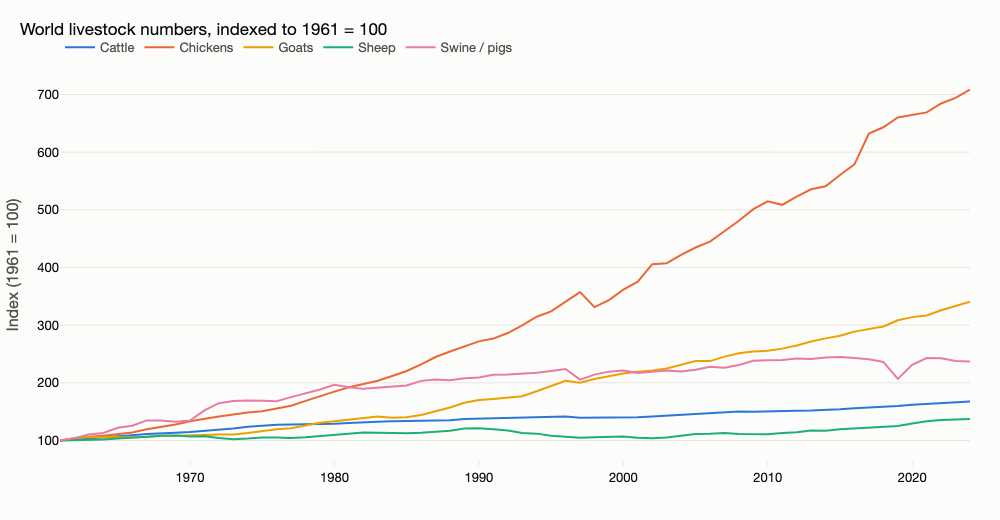

- Head counts in 2024: Chickens 27,681 M, Cattle 1,579 M, Sheep 1,363 M, Goats 1,188 M, Swine / pigs 962 M.
- Chickens grew 7.1x since 1961, goats 3.4x, cattle 1.7x, sheep 1.4x.

,item,year,element_code,value
0,Cattle,1961,5111,9.421221e+08
1,Cattle,1962,5111,9.571212e+08
2,Cattle,1963,5111,9.703314e+08
3,Cattle,1964,5111,9.875251e+08
4,Cattle,1965,5111,1.008857e+09
5,Cattle,1966,5111,1.027694e+09
6,Cattle,1967,5111,1.049721e+09
7,Cattle,1968,5111,1.064607e+09
8,Cattle,1969,5111,1.069827e+09
9,Cattle,1970,5111,1.081581e+09


In [13]:
livestock_stocks = answer("q35_livestock_stocks")

### Food security

#### Q08. How has the prevalence of undernourishment moved in each region since 2000?

```sql
-- Q08 How has the prevalence of undernourishment moved in each region since 2000?
SELECT f.area AS region, f.year, f.pou_pct, f.undernourished_m
FROM v_food_security f
WHERE f.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND f.pou_pct IS NOT NULL
ORDER BY f.area, f.year;
```

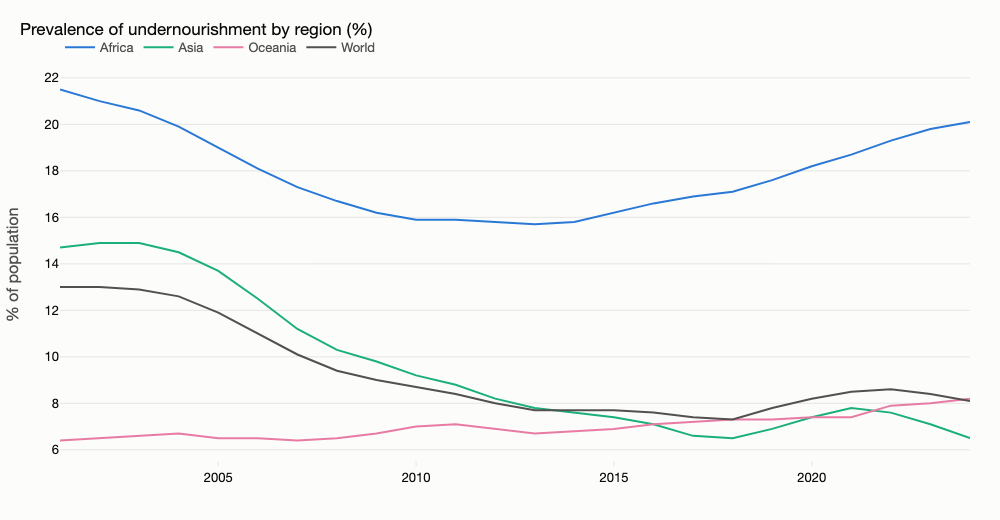

- World undernourishment fell from 13.0 % (2001) to a low of 7.3 % in 2018, then rose to 8.1 % in 2024 - 663 million people.
- Latest regional rates: Africa 20.1 %, Oceania 8.2 %, Asia 6.5 %.
- Africa is the only region above 15 %: 20.1 % in 2024, up from its 15.7 % low in 2013.

,region,year,pou_pct,undernourished_m
0,Africa,2001,21.5,183.0
1,Africa,2002,21.0,183.5
2,Africa,2003,20.6,184.4
3,Africa,2004,19.9,182.7
4,Africa,2005,19.0,178.9
5,Africa,2006,18.1,174.5
6,Africa,2007,17.3,171.8
7,Africa,2008,16.7,169.7
8,Africa,2009,16.2,169.3
9,Africa,2010,15.9,170.8


In [14]:
pou_by_region = answer("q08_pou_by_region")

#### Q09. Which countries have the highest undernourishment now, and where has it changed most since 2010?

```sql
-- Q09 Which countries have the highest undernourishment now, and where has it changed most since 2010?
SELECT area, region, year, pou_pct, undernourished_m
FROM v_food_security
WHERE is_aggregate = 0 AND region IS NOT NULL AND pou_pct IS NOT NULL AND year >= 2010;
```

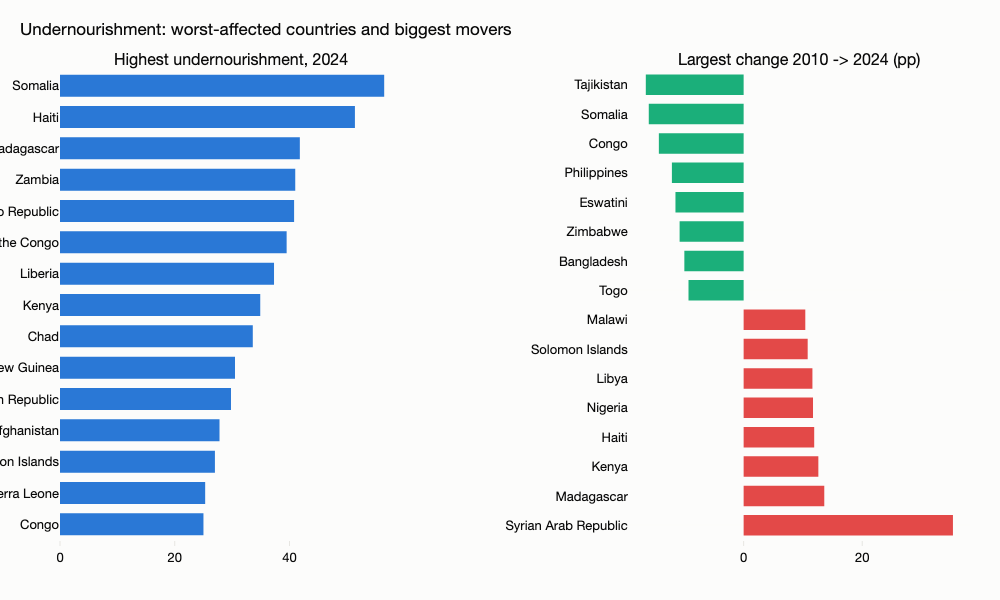

- Somalia (56 %), Haiti (51 %) and Madagascar (42 %) have the highest undernourishment in 2024.
- Biggest improvement since 2010: Tajikistan (-16 pp to 8 %). Biggest deterioration: Syrian Arab Republic (+35 pp to 41 %).
- 53 of 97 countries improved; 17 worsened by more than 5 pp.

,area,region,year,pou_pct,undernourished_m,pou_pct_2010,change_pp
76,Somalia,Africa,2024,56.5,10.7,72.5,-16.0
33,Haiti,Americas,2024,51.4,6.1,39.5,11.9
49,Madagascar,Africa,2024,41.8,13.3,28.2,13.6
96,Zambia,Africa,2024,41.0,8.7,43.8,-2.8
81,Syrian Arab Republic,Asia,2024,40.8,10.1,5.5,35.3
95,Democratic Republic of the Congo,Africa,2024,39.5,43.2,29.6,9.9
47,Liberia,Africa,2024,37.3,2.1,35.2,2.1
43,Kenya,Africa,2024,34.9,19.7,22.3,12.6
15,Chad,Africa,2024,33.6,6.8,24.1,9.5
65,Papua New Guinea,Oceania,2024,30.5,3.2,29.9,0.6


In [15]:
pou_change_countries = answer("q09_pou_change_countries")

#### Q10. How large is the gender gap in moderate-or-severe food insecurity, by region?

```sql
-- Q10 How large is the gender gap in moderate-or-severe food insecurity, by region?
SELECT area AS region, year, fies_mod_sev_f_pct, fies_mod_sev_m_pct,
       fies_mod_sev_f_pct - fies_mod_sev_m_pct AS gap_pp
FROM v_food_security
WHERE area_code IN (5000, 5100, 5200, 5300, 5400, 5500)
  AND fies_mod_sev_f_pct IS NOT NULL AND fies_mod_sev_m_pct IS NOT NULL
ORDER BY area, year;
```

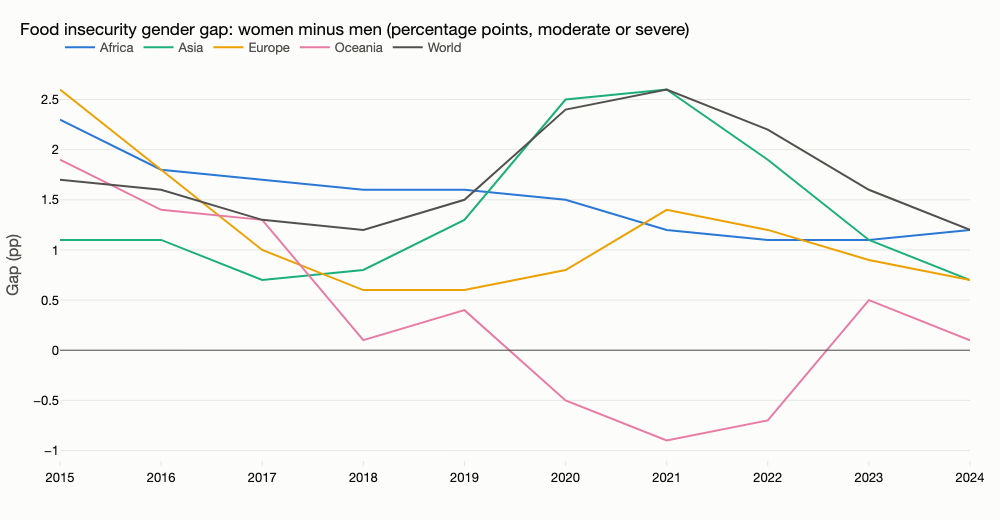

- Globally 24.7 % of women vs 23.5 % of men were moderately or severely food insecure in 2024 - a gap of +1.2 pp.
- Largest gaps: Africa +1.2 pp, Europe +0.7 pp, Asia +0.7 pp.
- The world gap peaked at +2.6 pp in 2021 (pandemic years).

,region,year,fies_mod_sev_f_pct,fies_mod_sev_m_pct,gap_pp
0,Africa,2015,46.2,43.9,2.3
1,Africa,2016,48.0,46.2,1.8
2,Africa,2017,49.8,48.1,1.7
3,Africa,2018,50.3,48.7,1.6
4,Africa,2019,51.4,49.8,1.6
5,Africa,2020,53.5,52.0,1.5
6,Africa,2021,55.3,54.1,1.2
7,Africa,2022,56.3,55.2,1.1
8,Africa,2023,56.8,55.7,1.1
9,Africa,2024,56.7,55.5,1.2


In [16]:
fies_gender_gap = answer("q10_fies_gender_gap")

#### Q11. How strongly is national income associated with undernourishment?

```sql
-- Q11 How strongly is national income associated with undernourishment?
WITH latest AS (
  SELECT area_code, MAX(year) AS y FROM v_food_security
  WHERE pou_pct IS NOT NULL AND gdp_cap_ppp IS NOT NULL GROUP BY area_code)
SELECT f.area, f.region, f.year, f.gdp_cap_ppp, f.pou_pct, p.population / 1e6 AS population_m
FROM v_food_security f
JOIN latest l ON l.area_code = f.area_code AND l.y = f.year
LEFT JOIN v_population p ON p.area_code = f.area_code AND p.year = f.year
WHERE f.is_aggregate = 0 AND f.region IS NOT NULL;
```

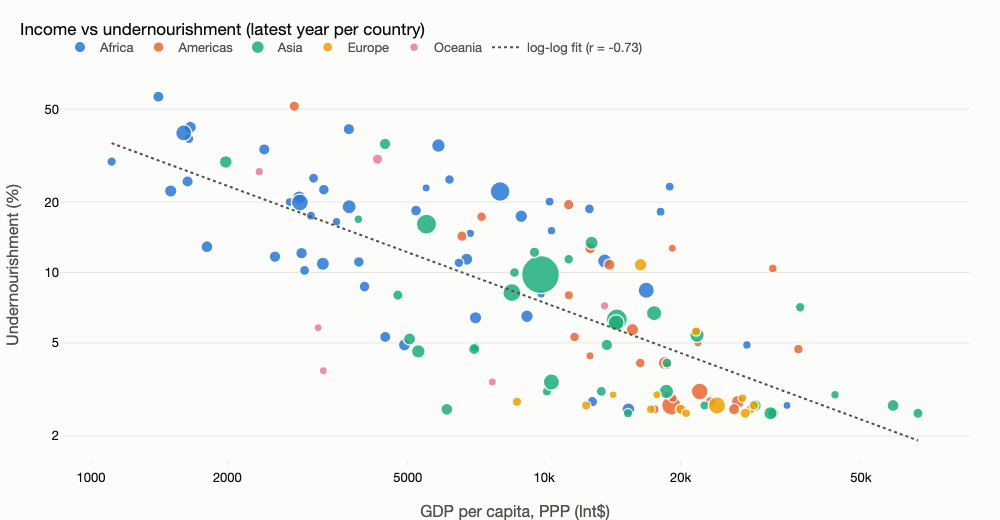

- Across 130 countries the log-log correlation between income and undernourishment is r = -0.73; each doubling of income is associated with a 39 % lower PoU.
- Countries above Int$ 30,000 per head have a maximum PoU of 10.4 % (2.5 % is FAO's reporting floor); below Int$ 3,000 the median PoU is 26 %.
- Worst performers for their income level: Trinidad and Tobago, Botswana, Gabon; best: Kiribati, Uzbekistan, Bosnia and Herzegovina.

,area,region,year,gdp_cap_ppp,pou_pct,population_m
0,Armenia,Asia,2009,10143.0,3.1,2.945517
1,Afghanistan,Asia,2023,1984.0,29.7,41.454761
2,Albania,Europe,2024,21641.0,5.6,2.791765
3,Algeria,Africa,2018,15343.0,2.6,42.505035
4,Angola,Africa,2024,8902.0,17.4,37.885849
5,Argentina,Americas,2024,26772.0,2.8,45.696159
6,Barbados,Americas,2024,21838.0,5.0,0.282467
7,Bangladesh,Asia,2024,8487.0,8.2,173.562364
8,Bolivia (Plurinational State of),Americas,2024,11329.0,19.5,12.413315
9,Botswana,Africa,2024,18069.0,18.2,2.521139


In [17]:
income_vs_pou = answer("q11_income_vs_pou")

#### Q12. Does dietary energy supply adequacy explain child stunting?

```sql
-- Q12 Does dietary energy supply adequacy explain child stunting?
WITH latest AS (
  SELECT area_code, MAX(year) AS y FROM v_food_security
  WHERE stunting_pct IS NOT NULL AND des_adequacy_pct IS NOT NULL GROUP BY area_code)
SELECT f.area, f.region, f.year, f.des_adequacy_pct, f.stunting_pct, f.sanitation_basic_pct, f.water_basic_pct
FROM v_food_security f JOIN latest l ON l.area_code = f.area_code AND l.y = f.year
WHERE f.is_aggregate = 0 AND f.region IS NOT NULL;
```

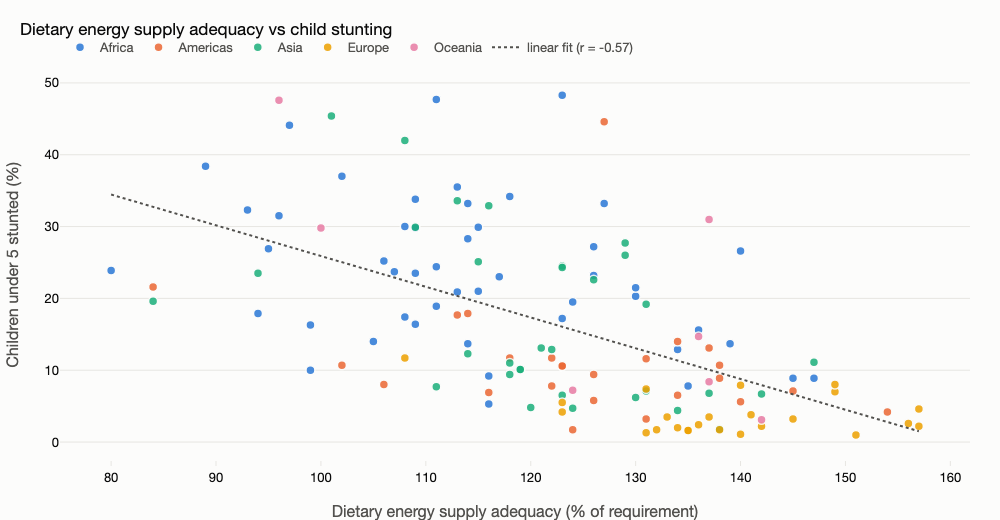

- Energy adequacy alone explains stunting only moderately (r = -0.57, n = 136); 14 countries with >= 120 % adequacy still have stunting above 20 %.
- Basic sanitation coverage correlates more strongly with stunting (r = -0.73) - calories are necessary but not sufficient.
- Highest stunting: Niger 48 %, Angola 48 %, Papua New Guinea 48 %.

,area,region,year,des_adequacy_pct,stunting_pct,sanitation_basic_pct,water_basic_pct
0,Armenia,Asia,2024,130.0,6.2,94.0,100.0
1,Afghanistan,Asia,2024,108.0,42.0,54.0,81.0
2,Albania,Europe,2024,131.0,7.4,99.0,95.0
3,Algeria,Africa,2024,147.0,8.9,86.0,92.0
4,Angola,Africa,2024,111.0,47.7,NaN,68.0
5,Argentina,Americas,2024,138.0,10.7,NaN,NaN
6,Australia,Oceania,2024,142.0,3.1,100.0,100.0
7,Barbados,Americas,2024,126.0,5.8,98.0,99.0
8,Bangladesh,Asia,2024,115.0,25.1,68.0,99.0
9,Bolivia (Plurinational State of),Americas,2024,102.0,10.7,72.0,93.0


In [18]:
stunting_vs_supply = answer("q12_stunting_vs_supply")

#### Q13. How is adult obesity trending by region, and how does it relate to income?

```sql
-- Q13 How is adult obesity trending by region, and how does it relate to income?
SELECT area AS region, year, obesity_pct
FROM v_food_security
WHERE area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND obesity_pct IS NOT NULL
ORDER BY area, year;
```

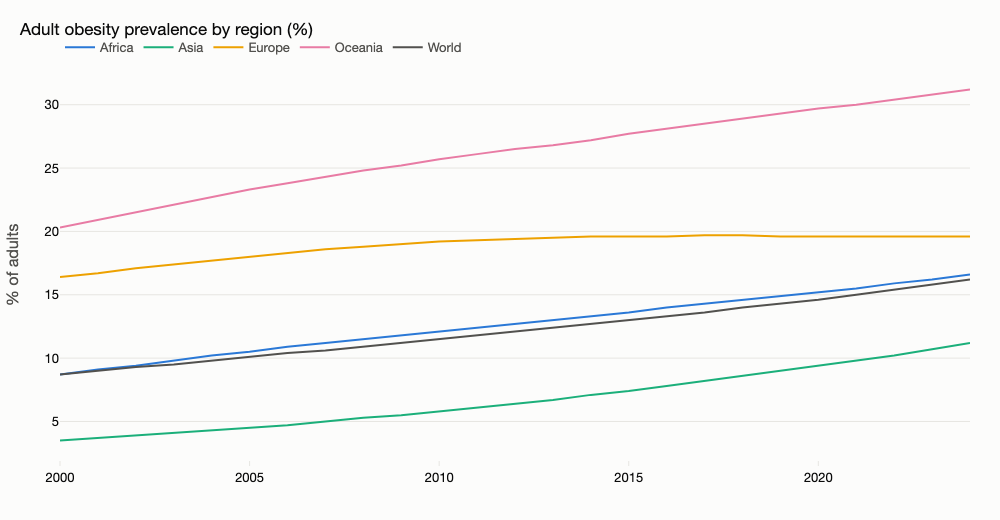

- World adult obesity rose from 8.7 % in 2000 to 16.2 % in 2024 - it has never fallen in a single year.
- Latest: Oceania 31.2 %, Europe 19.6 %, Africa 16.6 %, Asia 11.2 %.
- Fastest-rising region: Oceania.

,region,year,obesity_pct
0,Africa,2000,8.7
1,Africa,2001,9.1
2,Africa,2002,9.4
3,Africa,2003,9.8
4,Africa,2004,10.2
5,Africa,2005,10.5
6,Africa,2006,10.9
7,Africa,2007,11.2
8,Africa,2008,11.5
9,Africa,2009,11.8


In [19]:
obesity_trends = answer("q13_obesity_trends")

#### Q14. Which countries depend most on imported cereals?

```sql
-- Q14 Which countries depend most on imported cereals?
WITH latest AS (
  SELECT area_code, MAX(year) AS y FROM v_food_security WHERE cereal_import_dep_pct IS NOT NULL GROUP BY area_code)
SELECT f.area, f.region, f.year, f.cereal_import_dep_pct, f.food_import_share_pct, p.population / 1e6 AS population_m
FROM v_food_security f JOIN latest l ON l.area_code = f.area_code AND l.y = f.year
LEFT JOIN v_population p ON p.area_code = f.area_code AND p.year = f.year
WHERE f.is_aggregate = 0 AND f.region IS NOT NULL
ORDER BY f.cereal_import_dep_pct DESC;
```

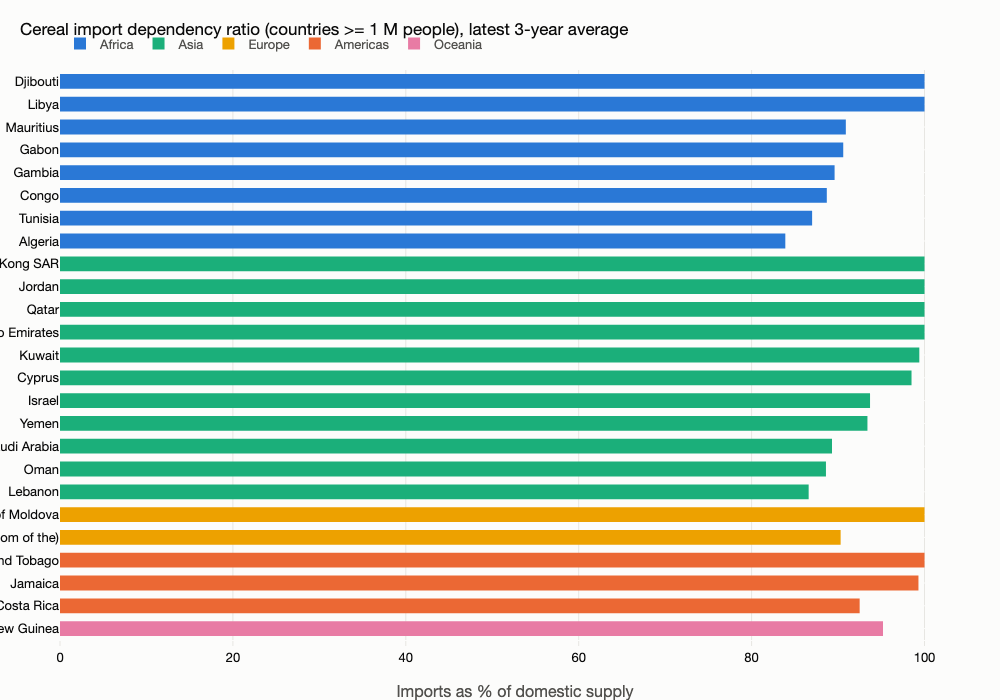

- 20 countries import essentially all (>= 99 %) of the cereals they consume, led by Djibouti, China, Hong Kong SAR, Jordan.
- 81 countries import at least half their cereals; 34 are net exporters (negative ratio).
- Regionally the median dependency is Oceania 96 %, Americas 58 %, Asia 48 %, Africa 43 %, Europe 20 %.

,area,region,year,cereal_import_dep_pct,food_import_share_pct,population_m
0,Antigua and Barbuda,Americas,2022,100.0,656.0,0.092840
1,Barbados,Americas,2022,100.0,86.0,0.282318
2,Solomon Islands,Oceania,2022,100.0,26.0,0.781066
3,Cabo Verde,Africa,2022,100.0,514.0,0.519741
4,Dominica,Americas,2008,100.0,111.0,0.068854
5,Djibouti,Africa,2022,100.0,43.0,1.137096
6,Grenada,Americas,2022,100.0,309.0,0.116913
7,"China, Hong Kong SAR",Asia,2022,100.0,3.0,7.465915
8,Jordan,Asia,2022,100.0,36.0,11.256263
9,Libya,Africa,2022,100.0,11.0,7.223805


In [20]:
cereal_import_dependency = answer("q14_cereal_import_dependency")

#### Q15. What does a healthy diet cost and who cannot afford it?

```sql
-- Q15 What does a healthy diet cost and who cannot afford it?
SELECT h.area_code, a.area, a.region, a.is_aggregate, h.year, h.cohd_ppp_per_day, h.unaffordable_pct, h.unaffordable_m
FROM v_healthy_diet h JOIN dim_area a USING (area_code)
WHERE (a.is_aggregate = 0 AND a.region IS NOT NULL) OR h.area_code IN (5000, 5100, 5200, 5300, 5400, 5500)
ORDER BY h.year, h.unaffordable_pct DESC;
```

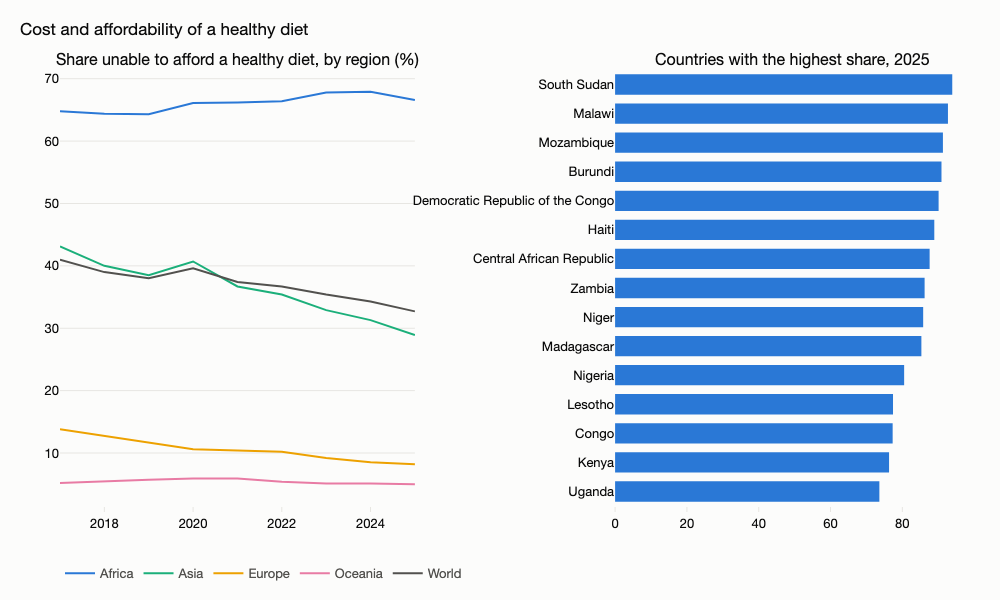

- A healthy diet cost 4.28 PPP$ per person per day in 2025, up from 2.94 in 2017.
- 32.7 % of the world's people (2,692 million) could not afford it in 2025, down from 41.0 % in 2017.
- Worst affected: South Sudan 94 %, Malawi 93 %, Mozambique 91 %.

,area_code,area,region,is_aggregate,year,cohd_ppp_per_day,unaffordable_pct,unaffordable_m
1367,277,South Sudan,Africa,0,2025,4.09,93.9,11.4
1368,130,Malawi,Africa,0,2025,5.01,92.7,20.6
1369,144,Mozambique,Africa,0,2025,4.49,91.3,32.5
1370,29,Burundi,Africa,0,2025,4.65,90.9,13.1
1371,250,Democratic Republic of the Congo,Africa,0,2025,2.66,90.1,101.7
1372,93,Haiti,Americas,0,2025,6.51,88.9,10.6
1373,37,Central African Republic,Africa,0,2025,4.34,87.6,4.8
1374,251,Zambia,Africa,0,2025,4.18,86.2,18.9
1375,158,Niger,Africa,0,2025,5.01,85.8,24.0
1376,129,Madagascar,Africa,0,2025,4.08,85.3,27.9


In [21]:
healthy_diet_affordability = answer("q15_healthy_diet_affordability")

### Inputs & land

#### Q16. How has nitrogen fertilizer use per hectare of cropland evolved by region?

```sql
-- Q16 How has nitrogen fertilizer use per hectare of cropland evolved by region?
SELECT a.area AS region, f.year, f.n_kg_per_ha, f.p2o5_kg_per_ha, f.k2o_kg_per_ha, f.n_use_t / 1e6 AS n_use_mt
FROM v_fertilizer f JOIN dim_area a USING (area_code)
WHERE f.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND f.n_kg_per_ha IS NOT NULL
ORDER BY a.area, f.year;
```

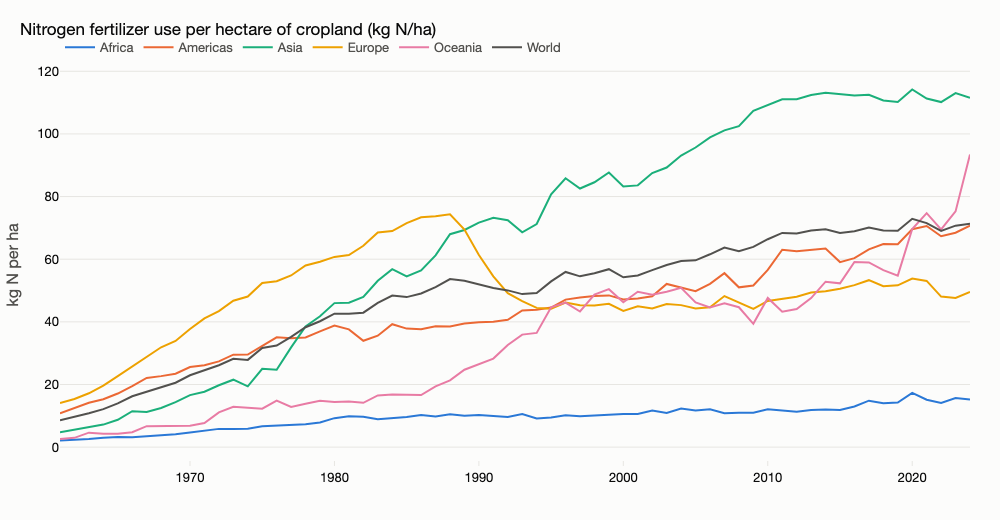

- World nitrogen use is 71 kg N/ha of cropland (115 Mt N in 2024), 8.3x the 1961 level.
- Latest intensity: Asia 112, Oceania 93, Americas 71, Europe 50, Africa 15 kg N/ha.
- Africa applies 7x less nitrogen per hectare than Asia.

,region,year,n_kg_per_ha,p2o5_kg_per_ha,k2o_kg_per_ha,n_use_mt
0,Africa,1961,2.12,1.60,0.58,0.352406
1,Africa,1962,2.27,1.74,0.64,0.379743
2,Africa,1963,2.62,1.83,0.73,0.443946
3,Africa,1964,2.98,1.92,0.92,0.509785
4,Africa,1965,3.24,2.09,0.92,0.558218
5,Africa,1966,3.14,2.43,1.06,0.544242
6,Africa,1967,3.45,2.67,1.10,0.599262
7,Africa,1968,3.84,2.78,1.18,0.674952
8,Africa,1969,4.13,2.83,1.16,0.731410
9,Africa,1970,4.69,3.09,1.28,0.834574


In [22]:
nitrogen_by_region = answer("q16_nitrogen_by_region")

#### Q17. How does nitrogen intensity relate to cereal yield across countries?

```sql
-- Q17 How does nitrogen intensity relate to cereal yield across countries?
SELECT p.area, p.region, p.year, f.n_kg_per_ha, p.yield_kg_ha / 1000.0 AS cereal_yield_t_ha, p.area_harvested_ha
FROM v_production p JOIN v_fertilizer f ON f.area_code = p.area_code AND f.year = p.year
WHERE p.item_code = '1717' AND p.is_aggregate = 0 AND p.region IS NOT NULL
  AND p.year = (SELECT MAX(year) FROM v_fertilizer WHERE n_kg_per_ha IS NOT NULL)
  AND f.n_kg_per_ha > 0 AND p.area_harvested_ha >= 50000;
```

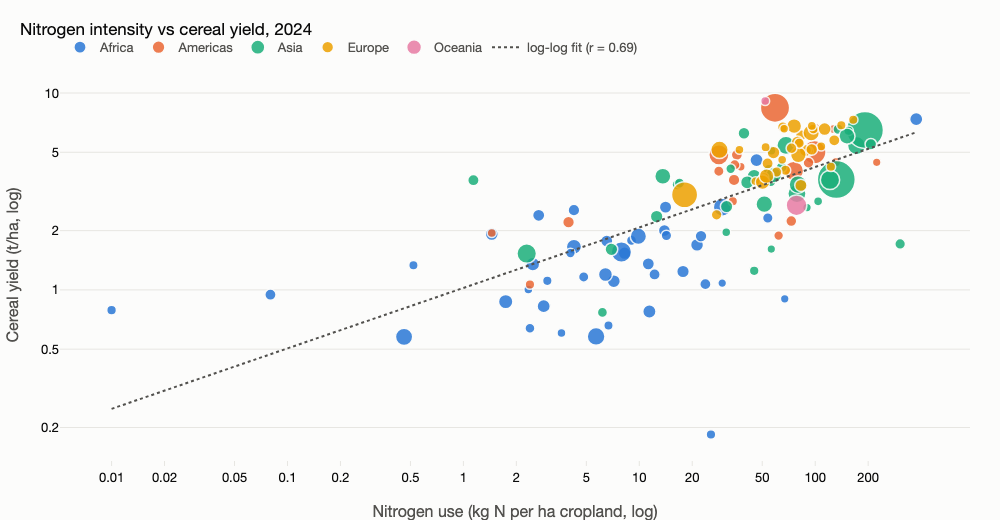

- Across 138 countries yield scales with nitrogen intensity at r = 0.69; a doubling of N/ha is associated with 24 % higher cereal yields.
- Diminishing returns are visible: countries above 150 kg N/ha average 5.6 t/ha vs 4.7 t/ha for 50-150 kg.
- Most nitrogen-efficient large producers (>= 1 Mha cereals, yield furthest above the fit): South Sudan, United States of America, Democratic People's Republic of Korea.

,area,region,year,n_kg_per_ha,cereal_yield_t_ha,area_harvested_ha
0,Armenia,Asia,2024,31.21,1.9611,109701.0
1,Afghanistan,Asia,2024,12.55,2.3586,2635327.0
2,Albania,Europe,2024,37.09,5.1528,126129.0
3,Algeria,Africa,2024,8.25,1.5366,2680109.0
4,Angola,Africa,2024,7.16,1.1066,3164046.0
5,Argentina,Americas,2024,28.34,4.8542,17660490.0
6,Australia,Oceania,2024,78.27,2.6897,19463223.0
7,Austria,Europe,2024,65.40,6.7218,726060.0
8,Bangladesh,Asia,2024,171.82,5.4080,12268360.0
9,Bolivia (Plurinational State of),Americas,2024,3.96,2.2090,1691778.0


In [23]:
fertilizer_vs_yield = answer("q17_fertilizer_vs_yield")

#### Q18. How is land used in each region, and how has cropland / pasture / forest changed since 1990?

```sql
-- Q18 How is land used in each region, and how has cropland / pasture / forest changed since 1990?
SELECT a.area AS region, l.year, l.land_area_kha, l.cropland_kha, l.pastures_kha, l.forest_kha, l.agri_land_kha
FROM v_land l JOIN dim_area a USING (area_code)
WHERE l.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND l.year IN (1990, 2000, 2010, 2020, 2022, 2023)
ORDER BY a.area, l.year;
```

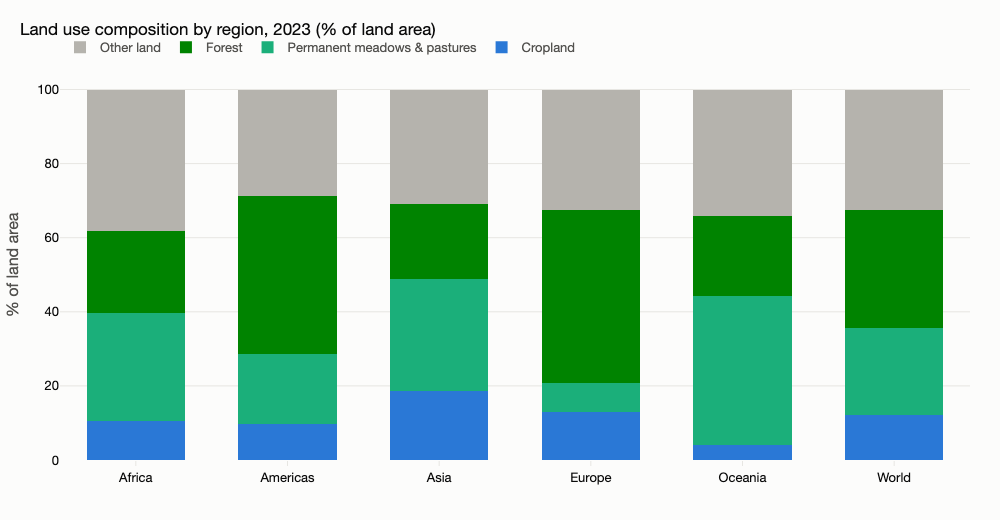

- Cropland covers 12 % of the world's land, pastures 24 % and forest 32 %.
- Since 1990 forest area fell 193 Mha globally (-4.5 %); Africa -14.3 %, Americas -9.2 %, Europe +2.5 %, Asia +10.5 %.
- Cropland expanded most in Africa (+52 %) and contracted in Europe (-22 %).

,region,crop0,crop1,for0,for1,past0,past1,cropland_chg_pct,forest_chg_pct,forest_chg_mha
0,Africa,204674.470,3.110635e+05,779535.63,668321.69,8.622652e+05,8.723504e+05,51.979619,-14.266691,-111.21394
1,Americas,376945.030,3.768521e+05,1799825.88,1634068.32,7.890469e+05,7.275708e+05,-0.024656,-9.209644,-165.75756
2,Asia,517710.220,5.765746e+05,568104.41,627589.18,7.167806e+05,9.464871e+05,11.370136,10.470746,59.48477
3,Europe,366760.610,2.862550e+05,1011651.74,1036585.80,4.091670e+05,1.714590e+05,-21.950438,2.464688,24.93406
4,Oceania,18996.795,3.399677e+04,184415.71,183660.03,4.613840e+05,3.416071e+05,78.960556,-0.409770,-0.75568
5,World,1485087.130,1.584742e+06,4343533.37,4150225.02,3.238644e+06,3.059474e+06,6.710370,-4.450486,-193.30835


In [24]:
land_use_by_region = answer("q18_land_use_by_region")

#### Q19. Is a higher share of irrigated arable land associated with higher cereal yields?

```sql
-- Q19 Is a higher share of irrigated arable land associated with higher cereal yields?
-- The FS indicator 21034 ("percent of arable land equipped for irrigation") is published
-- relative to *total land area* (Egypt = 4 %), so the ratio is rebuilt from the land-use
-- domain: land equipped for irrigation / (arable land + permanent crops).
WITH latest AS (
  SELECT area_code, MAX(year) AS y FROM v_land WHERE irrigated_equipped_kha IS NOT NULL AND arable_kha IS NOT NULL GROUP BY area_code)
SELECT a.area, a.region, l.year,
       100.0 * l.irrigated_equipped_kha / (l.arable_kha + COALESCE(l.perm_crops_kha, 0)) AS irrigation_share_pct,
       p.yield_kg_ha / 1000.0 AS cereal_yield_t_ha, p.area_harvested_ha
FROM v_land l JOIN latest ON latest.area_code = l.area_code AND latest.y = l.year
JOIN dim_area a ON a.area_code = l.area_code
JOIN v_production p ON p.area_code = l.area_code AND p.year = l.year AND p.item_code = '1717'
WHERE a.is_aggregate = 0 AND a.region IS NOT NULL AND p.area_harvested_ha >= 50000 AND l.arable_kha > 0;
```

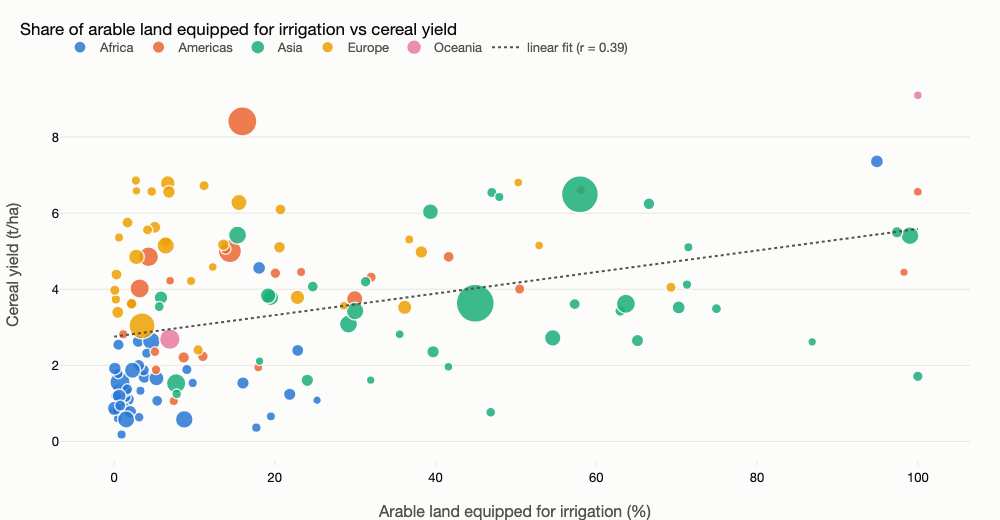

- Irrigation share and cereal yield correlate at r = 0.39 across 141 countries; each additional 10 pp of irrigated arable land is associated with +0.28 t/ha.
- Countries with under 5 % irrigated arable land average 2.5 t/ha; those above 40 % average 4.6 t/ha.
- Rain-fed high performers (< 10 % irrigated, > 6 t/ha): Germany, Croatia, Slovenia, United Kingdom of Great Britain and Northern Ireland, Belgium.
- Data note: FAOSTAT's food-security indicator 21034 reports Egypt at 4 % 'of arable land', i.e. it is effectively expressed against total land area; the ratio here is rebuilt from the land-use domain (RL 6690 / (6621 + 6650)).

,area,region,year,irrigation_share_pct,cereal_yield_t_ha,area_harvested_ha
0,Armenia,Asia,2024,41.597139,1.9611,109701.0
1,Afghanistan,Asia,2024,39.693145,2.3586,2635327.0
2,Albania,Europe,2024,52.888023,5.1528,126129.0
3,Algeria,Africa,2024,16.033924,1.5366,2680109.0
4,Angola,Africa,2024,1.736872,1.1066,3164046.0
5,Argentina,Americas,2024,4.291325,4.8542,17660490.0
6,Australia,Oceania,2024,6.938167,2.6897,19463223.0
7,Austria,Europe,2024,11.200295,6.7218,726060.0
8,Bangladesh,Asia,2024,99.022616,5.4080,12268360.0
9,Bolivia (Plurinational State of),Americas,2024,8.662324,2.2090,1691778.0


In [25]:
irrigation_vs_yield = answer("q19_irrigation_vs_yield")

#### Q20. How fast is organically farmed agricultural area growing?

```sql
-- Q20 How fast is organically farmed agricultural area growing?
SELECT a.area AS region, l.year, l.organic_agri_kha, l.agri_land_kha,
       100.0 * l.organic_agri_kha / l.agri_land_kha AS organic_share_pct
FROM v_land l JOIN dim_area a USING (area_code)
WHERE l.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND l.organic_agri_kha IS NOT NULL
ORDER BY a.area, l.year;
```

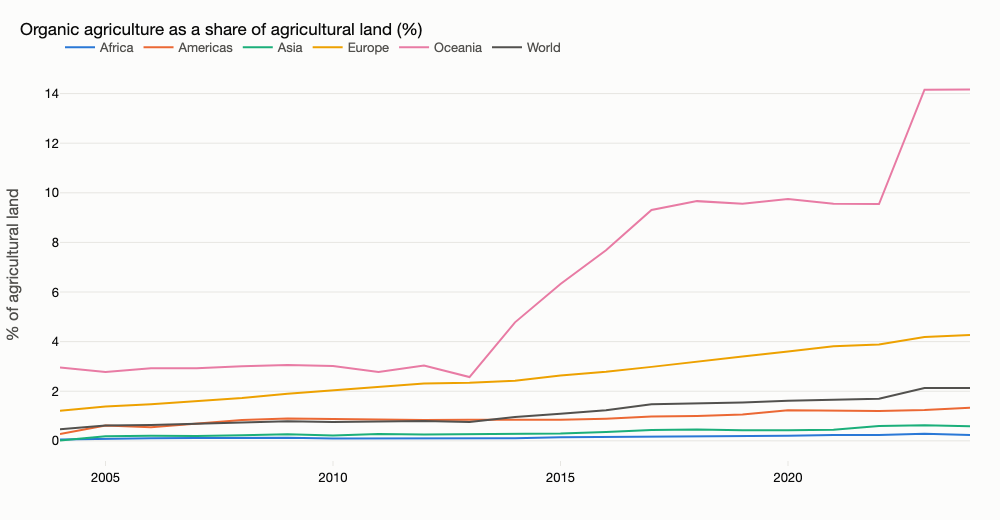

- Organic farming covers 99 Mha worldwide (2.13 % of agricultural land) in 2024, 4.5x the 2004 area.
- Regional shares: Oceania 14.16 %, Europe 4.26 %, Americas 1.33 %, Asia 0.59 %, Africa 0.24 %.

,region,year,organic_agri_kha,agri_land_kha,organic_share_pct
0,Africa,2004,624.20,1112100.09,0.056128
1,Africa,2005,952.89,1120120.42,0.085070
2,Africa,2006,1149.90,1122356.78,0.102454
3,Africa,2007,1271.07,1126494.78,0.112834
4,Africa,2008,1256.39,1129590.23,0.111225
5,Africa,2009,1413.44,1132938.84,0.124759
6,Africa,2010,1023.58,1141845.06,0.089643
7,Africa,2011,1022.40,1144034.71,0.089368
8,Africa,2012,1093.43,1150061.68,0.095076
9,Africa,2013,1077.57,1153881.65,0.093387


In [26]:
organic_agriculture = answer("q20_organic_agriculture")

### Climate & emissions

#### Q21. How much has land surface temperature changed in each region (vs the 1951-1980 baseline)?

```sql
-- Q21 How much has land surface temperature changed in each region (vs the 1951-1980 baseline)?
SELECT a.area AS region, t.year, t.temp_change_c
FROM v_temperature t JOIN dim_area a USING (area_code)
WHERE t.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND t.temp_change_c IS NOT NULL
ORDER BY a.area, t.year;
```

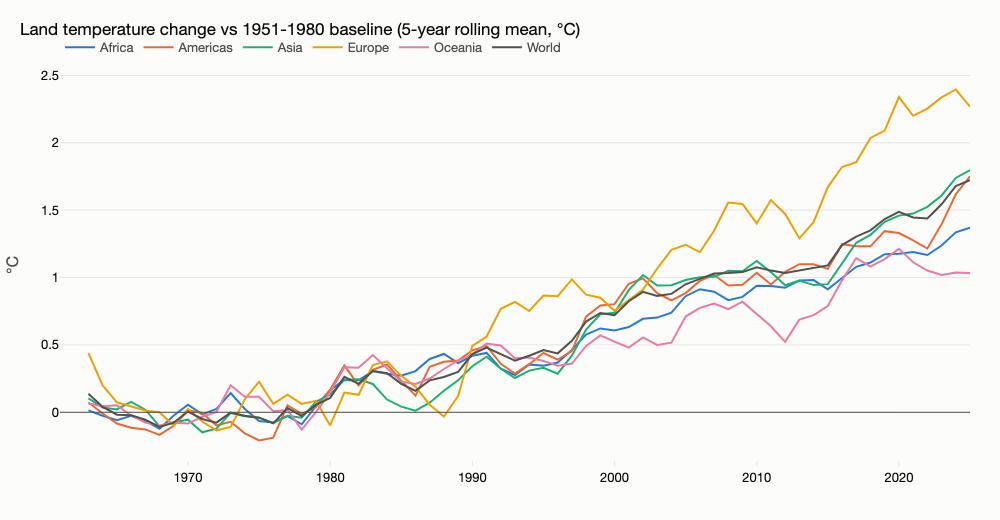

- World land temperature in the last five years averaged +1.72 °C above the 1951-1980 baseline; the single warmest year was 2024 at +2.11 °C.
- Five-year mean by region: Europe +2.27 °C, Asia +1.80 °C, Americas +1.75 °C, Africa +1.37 °C, Oceania +1.03 °C.
- Europe has warmed fastest; Oceania least. The 1960s world average was -0.02 °C.

,region,year,temp_change_c
0,Africa,1961,-0.009
1,Africa,1962,-0.025
2,Africa,1963,0.077
3,Africa,1964,-0.143
4,Africa,1965,-0.189
5,Africa,1966,0.147
6,Africa,1967,-0.206
7,Africa,1968,-0.221
8,Africa,1969,0.349
9,Africa,1970,0.216


In [27]:
temperature_by_region = answer("q21_temperature_by_region")

#### Q22. How large are agrifood-system emissions by region, and what share of all emissions are they?

```sql
-- Q22 How large are agrifood-system emissions by region, and what share of all emissions are they?
SELECT a.area AS region, e.year, e.agrifood_kt_co2eq / 1e6 AS agrifood_gt,
       e.farm_gate_kt_co2eq / 1e6 AS farm_gate_gt, e.land_use_change_kt_co2eq / 1e6 AS luc_gt,
       e.pre_post_kt_co2eq / 1e6 AS pre_post_gt,
       100.0 * e.agrifood_kt_co2eq / e.all_sectors_kt_co2eq AS agrifood_share_pct
FROM v_emissions e JOIN dim_area a USING (area_code)
WHERE e.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND e.agrifood_kt_co2eq IS NOT NULL
ORDER BY a.area, e.year;
```

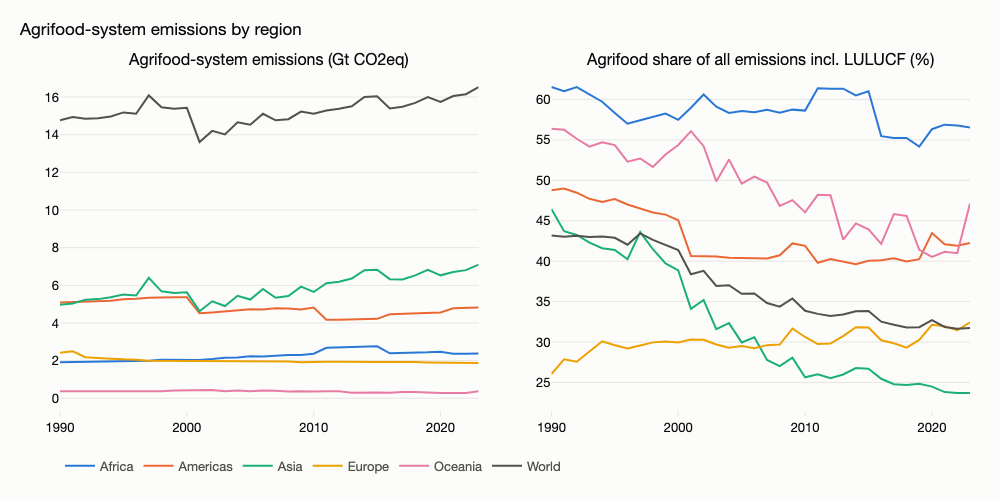

- Global agrifood systems emitted 16.5 Gt CO2eq in 2023 - 32 % of all anthropogenic emissions - split into farm gate 8.1 Gt, land-use change 3.2 Gt and pre/post-production 5.2 Gt.
- Since 1990 agrifood emissions rose 12 % while their share of the total fell from 43 % to 32 % as energy emissions grew faster.
- Latest by region: Asia 7.10 Gt, Americas 4.82 Gt, Africa 2.38 Gt, Europe 1.87 Gt, Oceania 0.37 Gt.

,region,year,agrifood_gt,farm_gate_gt,luc_gt,pre_post_gt,agrifood_share_pct
0,Africa,1990,1.907884,0.691209,1.058622,0.158054,61.540810
1,Africa,1991,1.917701,0.694539,1.058622,0.164541,61.012267
2,Africa,1992,1.929793,0.703787,1.058622,0.167384,61.534261
3,Africa,1993,1.934993,0.704805,1.058622,0.171566,60.665299
4,Africa,1994,1.951810,0.716525,1.058622,0.176664,59.715933
5,Africa,1995,1.970426,0.728732,1.058622,0.183072,58.336615
6,Africa,1996,1.964886,0.744652,1.031820,0.188414,56.996242
7,Africa,1997,1.988592,0.753322,1.039697,0.195574,57.436885
8,Africa,1998,2.052876,0.793384,1.059642,0.199849,57.834335
9,Africa,1999,2.050797,0.797413,1.048162,0.205222,58.251317


In [28]:
agrifood_emissions_by_region = answer("q22_agrifood_emissions_by_region")

#### Q23. Which countries have the highest agrifood emissions per person, and how does that relate to income?

```sql
-- Q23 Which countries have the highest agrifood emissions per person, and how does that relate to income?
WITH latest AS (SELECT MAX(year) AS y FROM v_emissions WHERE agrifood_kt_co2eq IS NOT NULL)
SELECT a.area, a.region, e.year,
       e.agrifood_kt_co2eq * 1000.0 / p.population AS agrifood_t_per_cap,
       e.farm_gate_kt_co2eq * 1000.0 / p.population AS farm_gate_t_per_cap,
       p.population / 1e6 AS population_m, f.gdp_cap_ppp
FROM v_emissions e JOIN latest ON e.year = latest.y
JOIN dim_area a USING (area_code)
JOIN v_population p ON p.area_code = e.area_code AND p.year = e.year
LEFT JOIN v_food_security f ON f.area_code = e.area_code AND f.year = e.year
WHERE a.is_aggregate = 0 AND a.region IS NOT NULL AND p.population > 1e6;
```

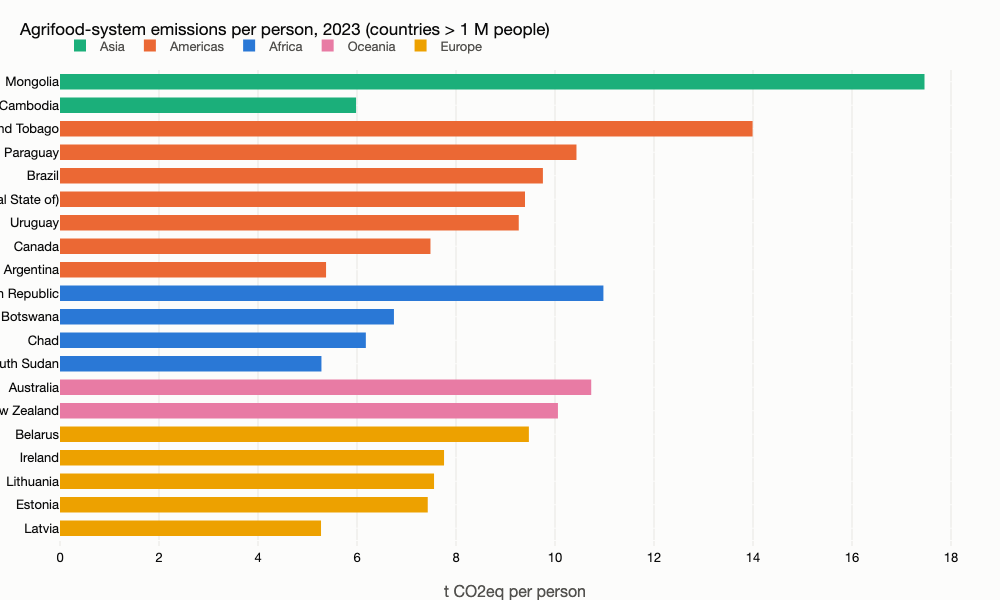

- Mongolia (17.5 t), Trinidad and Tobago (14.0 t) and Central African Republic (11.0 t) have the highest agrifood emissions per person - land-use change and cattle dominate.
- The population-weighted world average is 2.04 t per person; the median country is 1.92 t.
- Per-capita agrifood emissions are only weakly tied to income (log-log r = 0.31) - unlike energy emissions, they follow land and livestock.

,area,region,year,agrifood_t_per_cap,farm_gate_t_per_cap,population_m,gdp_cap_ppp
0,Armenia,Asia,2023,1.052021,0.487131,2.943393,19403.0
1,Afghanistan,Asia,2023,0.546407,0.389792,41.454761,1984.0
2,Albania,Europe,2023,1.380089,0.874257,2.811655,20481.0
3,Algeria,Africa,2023,1.403378,0.338023,46.164219,15159.0
4,Angola,Africa,2023,2.281793,0.979015,36.749906,8788.0
5,Argentina,Americas,2023,5.374832,3.314374,45.538401,27230.0
6,Australia,Oceania,2023,10.731266,8.578328,26.451124,60685.0
7,Austria,Europe,2023,1.991404,0.943116,9.130429,64536.0
8,Bahrain,Asia,2023,2.563932,0.055388,1.569666,57820.0
9,Bangladesh,Asia,2023,0.838791,0.662273,171.466990,8242.0


In [29]:
emissions_per_capita = answer("q23_emissions_per_capita")

#### Q24. Do hotter-than-usual years coincide with below-trend wheat yields?

```sql
-- Q24 Do hotter-than-usual years coincide with below-trend wheat yields?
SELECT p.area, p.region, p.year, p.yield_kg_ha / 1000.0 AS wheat_yield_t_ha, t.temp_change_c, p.area_harvested_ha
FROM v_production p JOIN v_temperature t ON t.area_code = p.area_code AND t.year = p.year
WHERE p.item_code = '15' AND p.is_aggregate = 0 AND p.region IS NOT NULL AND p.year >= 1990
  AND p.area_harvested_ha >= 200000;
```

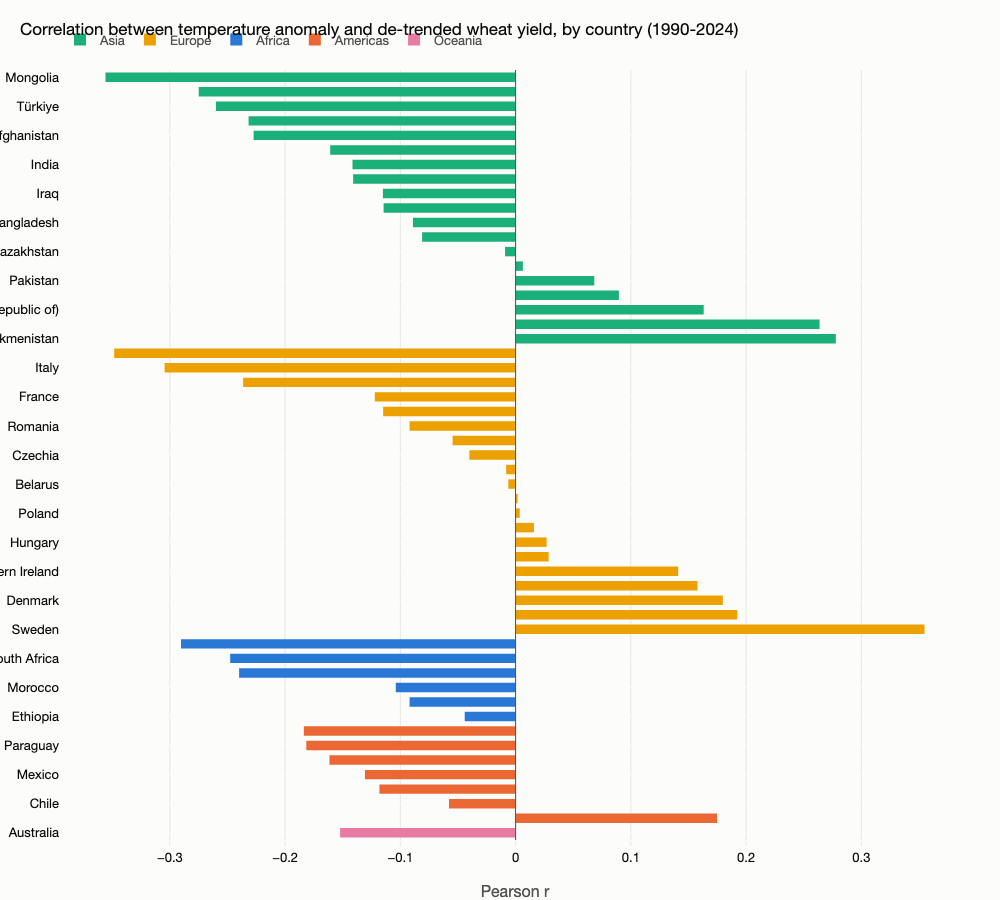

- In 68 % of the 53 major wheat producers, hotter-than-usual years coincide with below-trend yields (negative r); the median correlation is -0.09.
- Most heat-sensitive: Mongolia (r = -0.36), Republic of Moldova (r = -0.35), Italy (r = -0.30).
- Heat-tolerant or cold-limited systems where warm years help: Kyrgyzstan (r = +0.26), Turkmenistan (r = +0.28), Sweden (r = +0.35).

,area,region,r,n,mean_area_ha
30,Mongolia,Asia,-0.355812,28,3.390001e+05
36,Republic of Moldova,Europe,-0.348243,33,3.489456e+05
24,Italy,Europe,-0.304503,35,2.104991e+06
1,Algeria,Africa,-0.290298,35,1.689085e+06
45,Tajikistan,Asia,-0.274930,30,3.006423e+05
48,Türkiye,Asia,-0.260021,35,8.340299e+06
41,South Africa,Africa,-0.247629,35,7.777424e+05
15,Egypt,Africa,-0.239902,35,1.186323e+06
42,Spain,Europe,-0.236399,35,2.091316e+06
32,Nepal,Asia,-0.231664,35,6.837840e+05


In [30]:
temperature_vs_wheat_yield = answer("q24_temperature_vs_wheat_yield")

#### Q25. What makes up farm-gate emissions globally and how has the mix changed?

```sql
-- Q25 What makes up farm-gate emissions globally and how has the mix changed?
SELECT year, enteric_kt_co2eq / 1e6 AS enteric_gt, manure_mgmt_kt_co2eq / 1e6 AS manure_gt,
       rice_kt_co2eq / 1e6 AS rice_gt, synthetic_fert_kt_co2eq / 1e6 AS synthetic_fert_gt,
       farm_gate_kt_co2eq / 1e6 AS farm_gate_gt
FROM v_emissions WHERE area_code = 5000 AND farm_gate_kt_co2eq IS NOT NULL ORDER BY year;
```

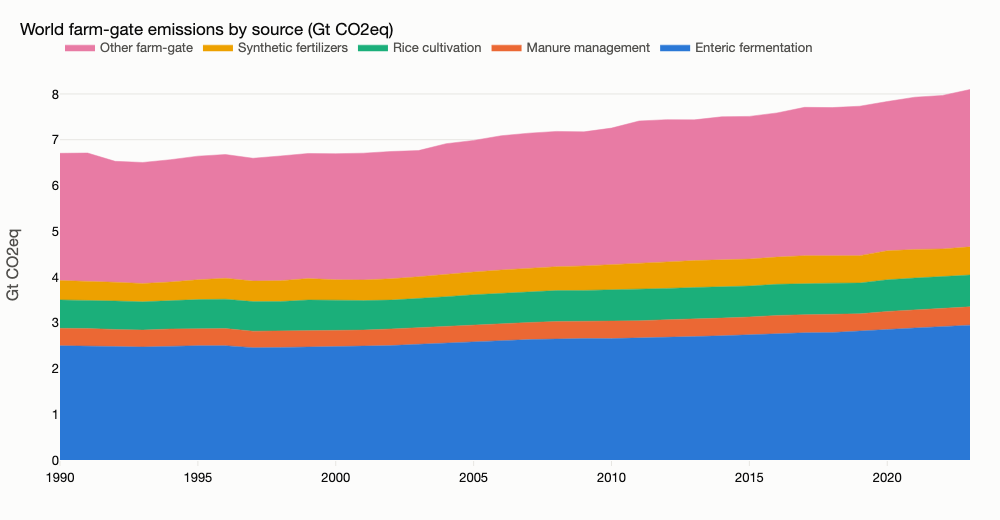

- Farm-gate emissions reached 8.10 Gt CO2eq in 2023: enteric fermentation 36 %, manure 5 %, synthetic fertilizers 8 %, rice 9 %.
- Synthetic-fertilizer emissions grew fastest since 1990 (1.4x) versus 1.2x for enteric fermentation.

,year,enteric_gt,manure_gt,rice_gt,synthetic_fert_gt,farm_gate_gt
0,1990,2.497633,0.380055,0.620855,0.425466,6.702661
1,1991,2.496306,0.378655,0.618042,0.416416,6.708880
2,1992,2.479925,0.372413,0.622718,0.410015,6.527311
3,1993,2.469870,0.370277,0.617200,0.400660,6.502759
4,1994,2.490448,0.372300,0.623370,0.403197,6.562411
5,1995,2.498493,0.372284,0.634714,0.433965,6.640587
6,1996,2.498927,0.372840,0.641748,0.458868,6.676143
7,1997,2.454672,0.361015,0.645474,0.448708,6.594290
8,1998,2.458970,0.362122,0.642220,0.456781,6.644521
9,1999,2.465599,0.362647,0.667379,0.468842,6.698718


In [31]:
farm_gate_composition = answer("q25_farm_gate_composition")

### People & prices

#### Q26. Is cereal production keeping up with population? Per-capita output by region.

```sql
-- Q26 Is cereal production keeping up with population? Per-capita output by region.
SELECT a.area AS region, p.year, p.production_t / pop.population * 1000.0 AS kg_per_capita,
       p.production_t / 1e6 AS production_mt, pop.population / 1e6 AS population_m
FROM v_production p JOIN v_population pop ON pop.area_code = p.area_code AND pop.year = p.year
JOIN dim_area a ON a.area_code = p.area_code
WHERE p.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND p.item_code = '1717'
ORDER BY a.area, p.year;
```

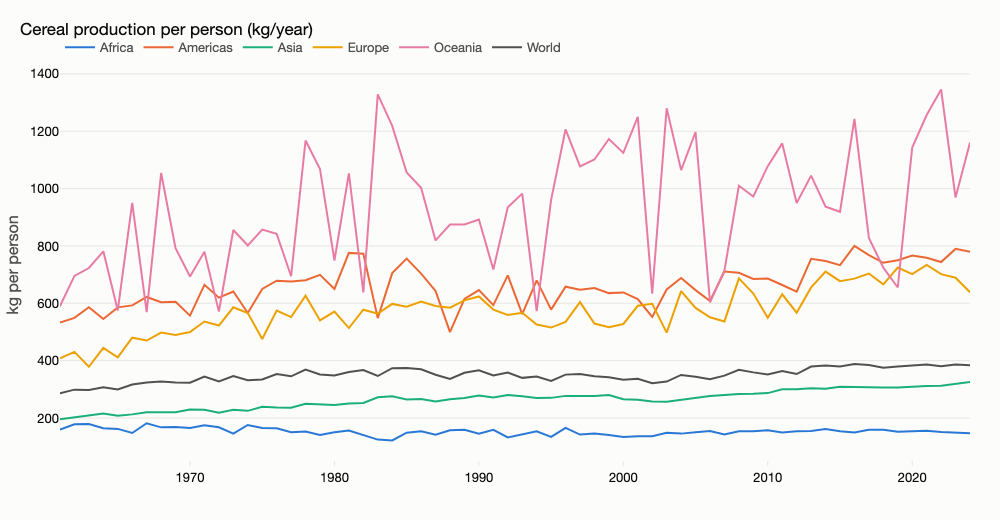

- World cereal output per person rose from 286 kg in 1961 to 384 kg in 2024 even as population grew from 3.1 to 8.2 billion.
- Latest by region: Oceania 1161 kg, Americas 779 kg, Europe 639 kg, Asia 325 kg, Africa 147 kg.
- Africa's per-capita output (147 kg) is 5.3x below the Americas'.

,region,year,kg_per_capita,production_mt,population_m
0,Africa,1961,159.245290,46.310719,290.813744
1,Africa,1962,178.188708,53.093043,297.959639
2,Africa,1963,178.696153,54.568632,305.371051
3,Africa,1964,164.224444,51.412170,313.060399
4,Africa,1965,161.918302,51.977920,321.013248
5,Africa,1966,147.731275,48.640817,329.251995
6,Africa,1967,181.669983,61.377334,337.850716
7,Africa,1968,167.252962,58.003434,346.800639
8,Africa,1969,168.167599,59.873091,356.032264
9,Africa,1970,165.422101,60.470359,365.551873


In [32]:
per_capita_cereal = answer("q26_per_capita_cereal")

#### Q27. How is urbanisation changing, and how much agricultural land is left per person?

```sql
-- Q27 How is urbanisation changing, and how much agricultural land is left per person?
SELECT a.area AS region, p.year, 100.0 * p.urban_population / p.population AS urban_share_pct,
       l.agri_land_kha * 1000.0 / p.population AS agri_ha_per_capita
FROM v_population p JOIN dim_area a USING (area_code)
LEFT JOIN v_land l ON l.area_code = p.area_code AND l.year = p.year
WHERE p.area_code IN (5000, 5100, 5200, 5300, 5400, 5500) AND p.urban_population IS NOT NULL
ORDER BY a.area, p.year;
```

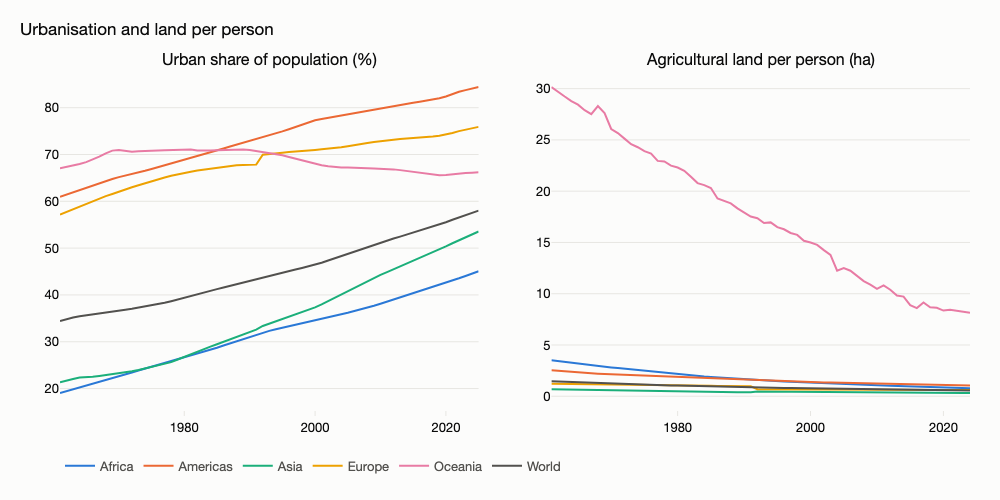

- The urban share of the world population rose from 34 % (1961) to 58 % (2024).
- Agricultural land per person fell from 1.47 ha to 0.57 ha over the same period (-61 %).

,region,year,urban_share_pct,agri_ha_per_capita
0,Africa,1961,19.050478,3.509486
1,Africa,1962,19.434238,3.424850
2,Africa,1963,19.831640,3.344833
3,Africa,1964,20.240890,3.263360
4,Africa,1965,20.668486,3.184997
5,Africa,1966,21.081726,3.108612
6,Africa,1967,21.460283,3.031576
7,Africa,1968,21.841043,2.958957
8,Africa,1969,22.228273,2.886387
9,Africa,1970,22.606195,2.813933


In [33]:
urbanisation_and_land = answer("q27_urbanisation_and_land")

#### Q28. How have producer prices for wheat, maize and rice moved across countries since 1991?

```sql
-- Q28 How have producer prices for wheat, maize and rice moved across countries since 1991?
SELECT item, year, usd_per_tonne, area_code FROM v_price_usd WHERE item_code IN ('15', '56', '27') AND usd_per_tonne > 0;
```

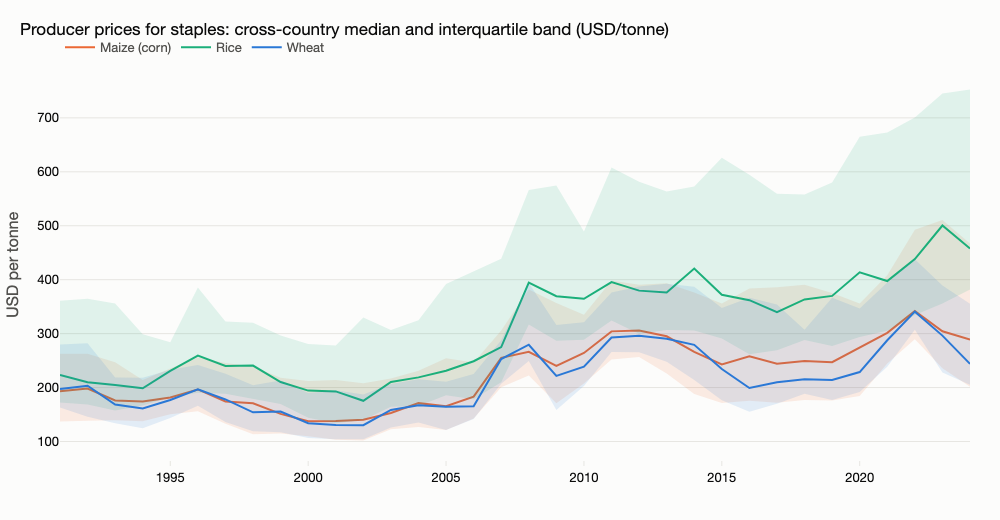

- Maize (corn): median producer price 289 USD/t in 2024, peak 342 USD/t in 2022; +17 % vs 2019.
- Rice: median producer price 458 USD/t in 2024, peak 500 USD/t in 2023; +24 % vs 2019.
- Wheat: median producer price 244 USD/t in 2024, peak 341 USD/t in 2022; +14 % vs 2019.

,item,year,median,q1,q3,n
0,Maize (corn),1991,193.20,137.250,262.675,78
1,Maize (corn),1992,198.15,138.350,262.800,84
2,Maize (corn),1993,176.10,139.200,246.800,91
3,Maize (corn),1994,174.20,137.600,213.950,98
4,Maize (corn),1995,181.65,150.575,235.375,104
5,Maize (corn),1996,196.50,156.100,255.900,101
6,Maize (corn),1997,174.10,133.100,245.700,101
7,Maize (corn),1998,170.90,113.525,239.225,106
8,Maize (corn),1999,151.10,114.825,218.050,102
9,Maize (corn),2000,137.70,109.600,212.000,105


In [34]:
staple_price_trends = answer("q28_staple_price_trends")

#### Q29. How dispersed are producer prices for staples across countries in the latest year?

```sql
-- Q29 How dispersed are producer prices for staples across countries in the latest year?
WITH latest AS (SELECT item_code, MAX(year) AS y FROM v_price_usd GROUP BY item_code)
SELECT p.item, a.area, a.region, p.year, p.usd_per_tonne
FROM v_price_usd p JOIN latest l ON l.item_code = p.item_code AND l.y = p.year
JOIN dim_area a USING (area_code)
WHERE p.item_code IN ('15', '56', '27', '116', '236', '882', '1062') AND p.usd_per_tonne > 0 AND a.region IS NOT NULL;
```

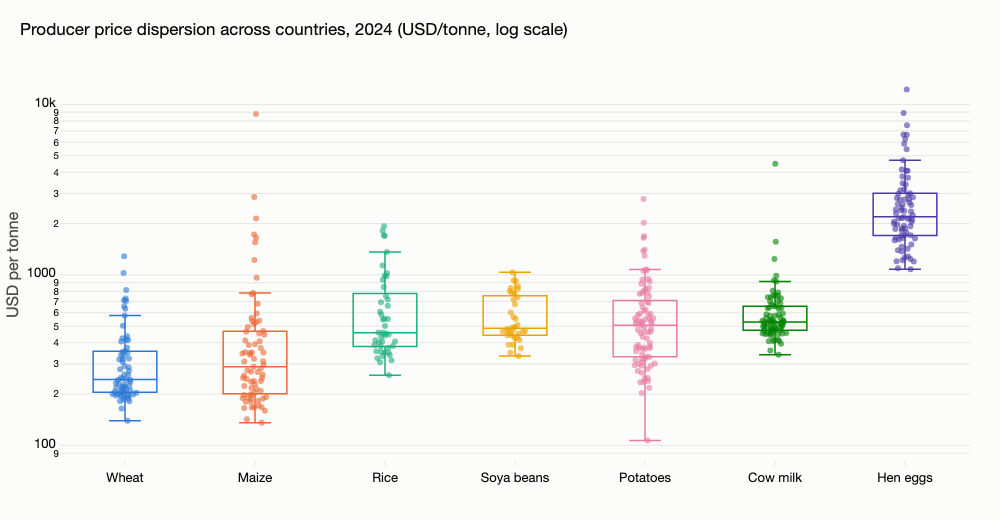

- The 90th/10th percentile price ratio across countries is widest for Maize (5.1x) and narrowest for Cow milk (1.8x).
- Median prices: Wheat 244, Maize 289, Rice 458, Soya beans 487, Potatoes 506, Cow milk 529, Hen eggs 2,194 USD/t.

,item,area,region,year,usd_per_tonne
0,"Hen eggs in shell, fresh",Armenia,Asia,2024,3167.4
1,"Hen eggs in shell, fresh",Albania,Europe,2024,5458.4
2,"Hen eggs in shell, fresh",Antigua and Barbuda,Americas,2024,6266.1
3,"Hen eggs in shell, fresh",Argentina,Americas,2024,1973.6
4,"Hen eggs in shell, fresh",Austria,Europe,2024,3394.8
5,"Hen eggs in shell, fresh",Bhutan,Asia,2024,2991.5
6,"Hen eggs in shell, fresh",Bolivia (Plurinational State of),Americas,2024,2047.3
7,"Hen eggs in shell, fresh",Brazil,Americas,2024,1093.0
8,"Hen eggs in shell, fresh",Belize,Americas,2024,2571.5
9,"Hen eggs in shell, fresh",Brunei Darussalam,Asia,2024,2952.9


In [35]:
price_dispersion = answer("q29_price_dispersion")

#### Q30. Where has cereal production growth lagged population growth since 2010?

```sql
-- Q30 Where has cereal production growth lagged population growth since 2010?
SELECT p.area, p.region, p.year, p.production_t, pop.population
FROM v_production p JOIN v_population pop ON pop.area_code = p.area_code AND pop.year = p.year
WHERE p.item_code = '1717' AND p.is_aggregate = 0 AND p.region IS NOT NULL AND p.year IN (2010, 2024);
```

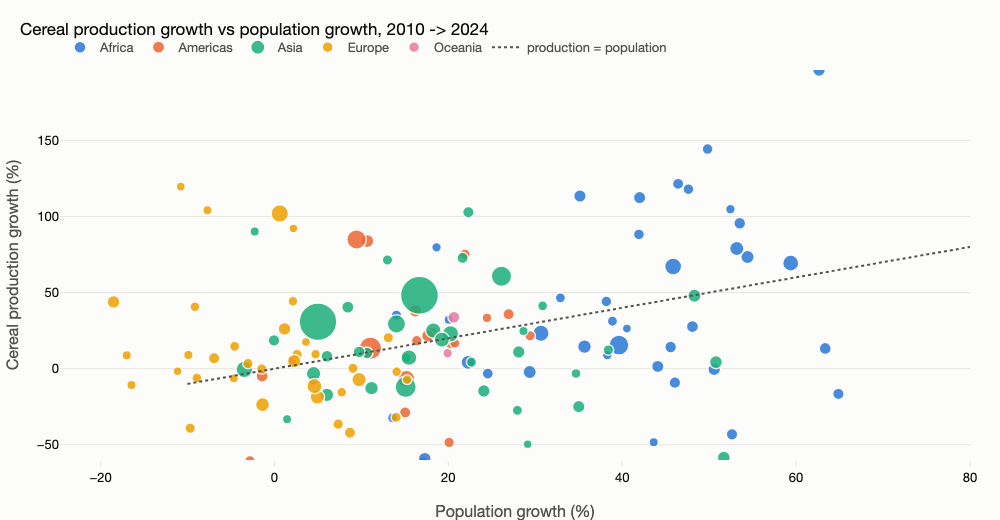

- In 68 of 136 countries cereal output grew slower than population between 2010 and 2024 (points below the diagonal).
- Largest shortfalls: Somalia (-119 pp), Yemen (-110 pp), Gambia (-109 pp), Zambia (-96 pp), Namibia (-92 pp).
- 41 African countries are in the sample; 23 of them fell behind population growth.

,area,region,prod_growth_pct,pop_growth_pct,population_m,gap_pp
145,Somalia,Africa,-64.008448,55.027967,19.009151,-119.036415
172,Yemen,Asia,-58.438020,51.687886,40.583164,-110.125906
61,Gambia,Africa,-65.614825,43.254699,2.759988,-108.869523
173,Zambia,Africa,-43.123963,52.624772,21.314956,-95.748735
111,Namibia,Africa,-48.267805,43.620969,3.030131,-91.888774
38,Costa Rica,Americas,-74.783100,12.597735,5.129910,-87.380834
31,Chad,Africa,-16.579315,64.864969,20.299123,-81.444284
155,Timor-Leste,Asia,-49.582948,29.129263,1.400638,-78.712211
91,Lesotho,Africa,-61.010636,17.090636,2.337423,-78.101272
108,Morocco,Africa,-59.086231,17.291879,38.081173,-76.378109


In [36]:
production_vs_population_growth = answer("q30_production_vs_population_growth")

### Composite & governance

#### Q31. A composite food-system scorecard: which countries combine adequate supply, low insecurity and low emissions intensity?

```sql
-- Q31 A composite food-system scorecard: which countries combine adequate supply, low insecurity and low emissions intensity?
-- Each indicator is taken at its own latest available year per country (they are published on different lags).
WITH c AS (SELECT area_code, area, region, is_ldc, is_sids, is_lldc FROM v_country)
SELECT c.area, c.region, c.is_ldc, c.is_sids, c.is_lldc,
  (SELECT pou_pct FROM v_food_security f WHERE f.area_code = c.area_code AND pou_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS pou_pct,
  (SELECT des_adequacy_pct FROM v_food_security f WHERE f.area_code = c.area_code AND des_adequacy_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS des_adequacy_pct,
  (SELECT stunting_pct FROM v_food_security f WHERE f.area_code = c.area_code AND stunting_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS stunting_pct,
  (SELECT obesity_pct FROM v_food_security f WHERE f.area_code = c.area_code AND obesity_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS obesity_pct,
  (SELECT cereal_import_dep_pct FROM v_food_security f WHERE f.area_code = c.area_code AND cereal_import_dep_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS cereal_import_dep_pct,
  (SELECT yield_kg_ha / 1000.0 FROM v_production v WHERE v.area_code = c.area_code AND v.item_code = '1717' AND yield_kg_ha IS NOT NULL ORDER BY year DESC LIMIT 1) AS cereal_yield_t_ha,
  (SELECT e.agrifood_kt_co2eq * 1000.0 / p.population FROM v_emissions e JOIN v_population p ON p.area_code = e.area_code AND p.year = e.year
     WHERE e.area_code = c.area_code AND e.agrifood_kt_co2eq IS NOT NULL ORDER BY e.year DESC LIMIT 1) AS agrifood_t_per_cap,
  (SELECT unaffordable_pct FROM v_healthy_diet h WHERE h.area_code = c.area_code AND unaffordable_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS unaffordable_pct,
  (SELECT temp_change_c FROM v_temperature t WHERE t.area_code = c.area_code AND temp_change_c IS NOT NULL ORDER BY year DESC LIMIT 1) AS temp_change_c
FROM c
WHERE pou_pct IS NOT NULL;
```

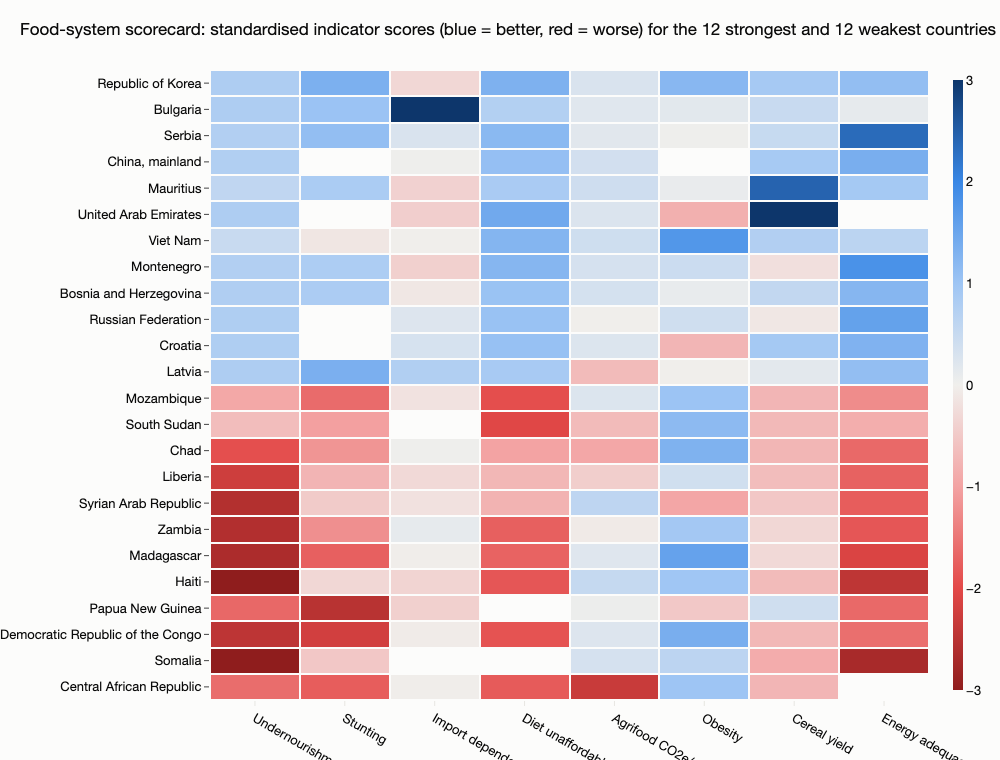

- Composite score across 8 indicators (n = 133 countries with >= 6): strongest Republic of Korea, Bulgaria, Serbia; weakest Democratic Republic of the Congo, Somalia, Central African Republic.
- Median score by region: Europe +0.53, Asia +0.20, Americas +0.05, Africa -0.28, Oceania -0.35.
- Least-developed countries score -0.31 on median versus +0.16 for the rest.

,area,region,score,n_indicators,pou_pct,stunting_pct,cereal_import_dep_pct,unaffordable_pct,agrifood_t_per_cap,obesity_pct,cereal_yield_t_ha,des_adequacy_pct
65,Republic of Korea,Asia,0.831656,8,2.5,1.8,78.5,5.3,1.888420,8.4,6.5444,138.0
13,Bulgaria,Europe,0.816465,8,2.6,5.5,-1015.6,20.7,2.198506,20.3,5.1032,123.0
134,Serbia,Europe,0.801780,8,3.0,4.6,-41.6,8.5,2.260247,21.8,5.1717,157.0
21,"China, mainland",Asia,0.751919,6,2.9,NaN,9.2,11.3,1.592767,NaN,6.4947,142.0
76,Mauritius,Africa,0.719491,8,4.9,7.8,90.9,17.8,1.421193,21.1,11.8902,135.0
122,United Arab Emirates,Asia,0.708109,6,2.5,NaN,100.0,1.9,1.980704,31.6,22.4743,NaN
129,Viet Nam,Asia,0.647083,8,6.1,19.2,15.4,7.0,1.443575,2.4,6.0378,131.0
135,Montenegro,Europe,0.600885,8,3.0,8.0,96.1,7.5,1.730496,17.1,2.6996,149.0
43,Bosnia and Herzegovina,Europe,0.597085,8,2.8,7.9,36.6,12.7,1.690115,21.0,5.3617,140.0
100,Russian Federation,Europe,0.560416,7,2.7,NaN,-32.1,12.4,2.910064,17.6,3.0420,145.0


In [37]:
food_system_scorecard = answer("q31_food_system_scorecard")

#### Q32. How much of each domain is official data versus estimated, imputed or externally sourced?

```sql
-- Q32 How much of each domain is official data versus estimated, imputed or externally sourced?
SELECT o.domain, d.name, o.flag, COALESCE(f.description, 'unspecified') AS description, COUNT(*) AS n
FROM observation o JOIN dim_domain d USING (domain)
LEFT JOIN dim_flag f ON f.domain = o.domain AND f.flag = o.flag
GROUP BY o.domain, o.flag ORDER BY o.domain, n DESC;
```

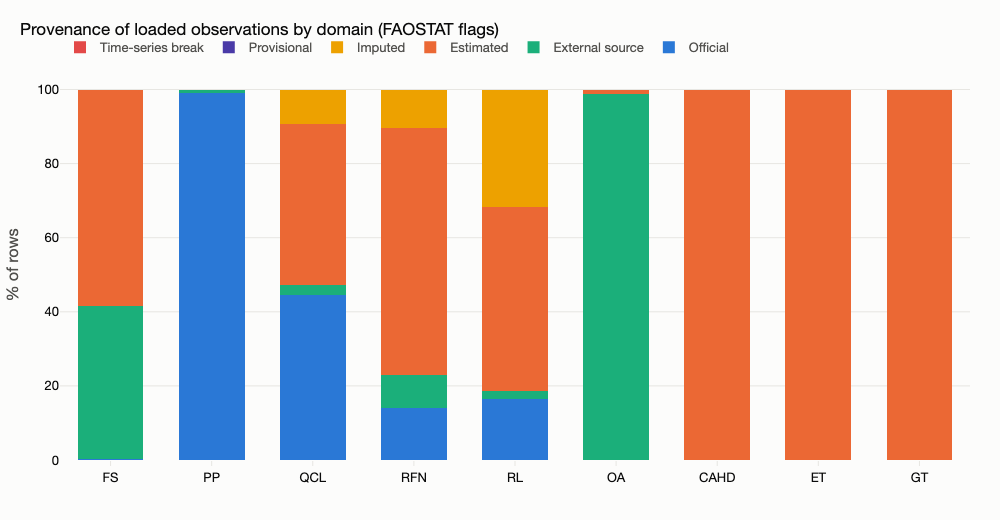

- Across all 7,333,827 loaded observations, 31 % carry the official flag, 57 % are FAO estimates, 7 % imputed and 4 % come from external organisations (UN population, WHO, World Bank).
- Only the production domain (QCL) is majority official (45 %); temperature, emissions and healthy-diet indicators are 100 % modelled estimates by construction.
- Analyses that lean on FS, RL and RFN should be read as FAO's best estimate rather than reported statistics.

,domain,flag_group,n,share
0,CAHD,Estimated,6894,100.000000
1,ET,Estimated,568179,100.000000
2,FS,Estimated,106561,58.441145
3,FS,External source,75367,41.333450
4,FS,Official,411,0.225404
5,GT,Estimated,1362938,100.000000
6,OA,Estimated,1051,1.283257
7,OA,External source,80850,98.716743
8,PP,External source,3094,0.913215
9,PP,Imputed,96,0.028335


In [38]:
data_provenance = answer("q32_data_provenance")

#### Q33. How do least-developed, land-locked and small-island states compare with everyone else?

```sql
-- Q33 How do least-developed, land-locked and small-island states compare with everyone else?
-- Each indicator is taken at its own latest available year per country.
WITH c AS (SELECT area_code, area, region, is_ldc, is_sids, is_lldc FROM v_country)
SELECT c.area, c.region,
       CASE WHEN c.is_ldc = 1 THEN 'Least developed' WHEN c.is_sids = 1 THEN 'Small island'
            WHEN c.is_lldc = 1 THEN 'Land-locked developing' ELSE 'Other' END AS grp,
  (SELECT pou_pct FROM v_food_security f WHERE f.area_code = c.area_code AND pou_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS pou_pct,
  (SELECT fies_mod_sev_pct FROM v_food_security f WHERE f.area_code = c.area_code AND fies_mod_sev_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS fies_mod_sev_pct,
  (SELECT cereal_import_dep_pct FROM v_food_security f WHERE f.area_code = c.area_code AND cereal_import_dep_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS cereal_import_dep_pct,
  (SELECT stunting_pct FROM v_food_security f WHERE f.area_code = c.area_code AND stunting_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS stunting_pct,
  (SELECT unaffordable_pct FROM v_healthy_diet h WHERE h.area_code = c.area_code AND unaffordable_pct IS NOT NULL ORDER BY year DESC LIMIT 1) AS unaffordable_pct,
  (SELECT yield_kg_ha / 1000.0 FROM v_production v WHERE v.area_code = c.area_code AND v.item_code = '1717' AND yield_kg_ha IS NOT NULL ORDER BY year DESC LIMIT 1) AS cereal_yield_t_ha
FROM c
WHERE pou_pct IS NOT NULL;
```

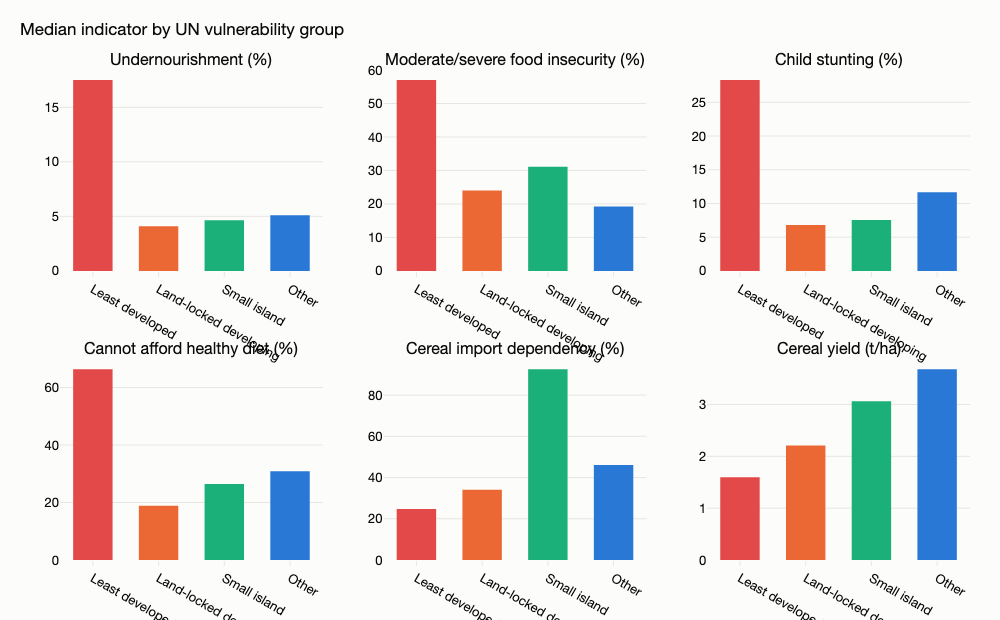

- Least-developed countries (n = 39) have median undernourishment of 18 % vs 5 % elsewhere, and 66 % cannot afford a healthy diet.
- Median cereal import dependency: Small island 93 %, Other 46 %, Land-locked developing 34 %, Least developed 25 % (n: LDC 39, LLDC 15, SIDS 20).
- Cereal yields: LDC median 1.6 t/ha vs 3.7 t/ha for other countries.

,grp,pou_pct,fies_mod_sev_pct,stunting_pct,unaffordable_pct,cereal_import_dep_pct,cereal_yield_t_ha
0,Least developed,17.50,57.00,28.30,66.40,24.80,1.59685
1,Land-locked developing,4.10,24.00,6.80,18.85,34.10,2.20900
2,Small island,4.65,31.10,7.55,26.40,92.60,3.06530
3,Other,5.10,19.25,11.65,30.90,46.05,3.68270


In [39]:
vulnerable_groups = answer("q33_vulnerable_groups")

## 4. Predictive models

Four models, each validated with a strictly time-based split (train on earlier years, test on later ones). They are descriptive screening aids trained on FAO's published - partly modelled - series; see `models/MODEL_CARD.md` for intended use and limitations.

In [40]:
from src import ml
panel = ml.build_panel(con)
print(f"feature panel: {len(panel):,} country-years · {panel.area_code.nunique()} countries · {panel.year.min()}–{panel.year.max()}")
panel[["area", "year", "cereal_yield_t_ha", "n_kg_per_ha", "temp_change_c", "pou_pct", "gdp_cap_ppp", "cereal_kg_per_cap"]].dropna().tail(6)


feature panel: 6,162 country-years · 183 countries · 1990–2024


,area,year,cereal_yield_t_ha,n_kg_per_ha,temp_change_c,pou_pct,gdp_cap_ppp,cereal_kg_per_cap
6111,Sudan,2016,0.6860,8.68,1.271,9.8,4175.0,206.568645
6112,Sudan,2017,0.6009,7.84,1.364,10.3,4061.0,129.229715
6113,Sudan,2018,0.7318,5.68,1.390,10.8,3817.0,200.652960
6114,Sudan,2019,0.5544,5.68,1.050,10.8,3626.0,123.956665
6115,Sudan,2020,0.5952,11.77,0.709,11.1,3401.0,122.016089
6116,Sudan,2021,0.5150,5.68,1.438,10.9,3249.0,107.453055


### 4.1 Next-year cereal-yield forecast

One step ahead, from lagged yields, last year's inputs and temperature, and region. Persistence (last year's yield) is the baseline every model must beat; the target year's own weather is excluded because a planner does not have it.

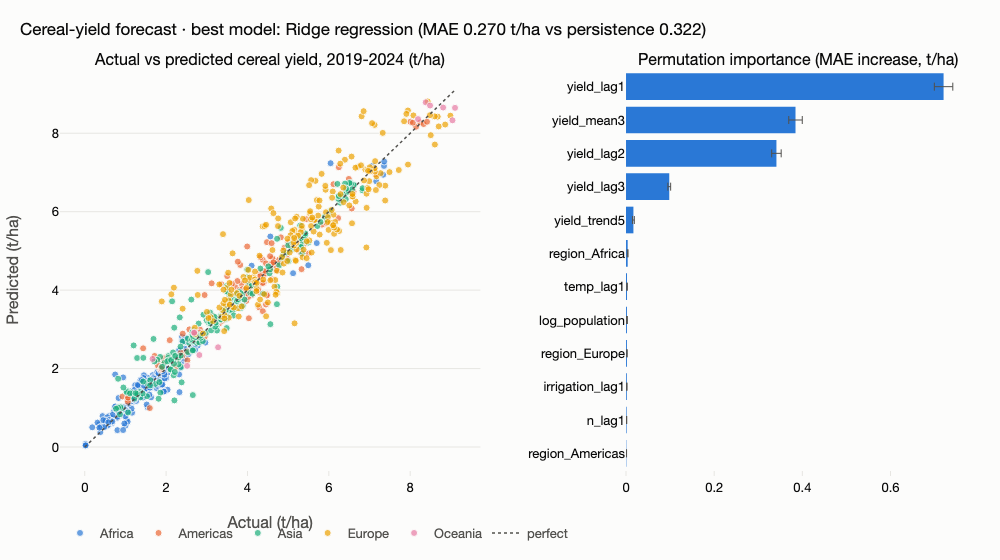

,mae,rmse,r2,mape_pct
Persistence (last year),0.322,0.540,0.932,11.239
Ridge regression,0.270,0.427,0.958,11.034
Gradient boosting,0.300,0.465,0.950,16.299


In [41]:
yield_metrics, fig = ml.yield_forecast(panel)
display(fig)
pd.DataFrame(yield_metrics["models"]).T.round(3)


In [42]:
print("best model:", yield_metrics["best"], "· split:", yield_metrics["split"])
display(pd.DataFrame(yield_metrics["top_features"]).round(3))
forecast = pd.read_csv(ROOT / "models" / "yield_forecast_next_year.csv")
forecast[forecast.cereal_area_ha >= 1e6].sort_values("change_pct", ascending=False).head(12).round(2)


best model: Ridge regression · split: train < 2019, test >= 2019


,feature,importance,std
0,yield_lag1,0.720,0.021
1,yield_mean3,0.384,0.015
2,yield_lag2,0.341,0.011
3,yield_lag3,0.098,0.003
4,yield_trend5,0.017,0.002
5,region_Africa,0.004,0.001


,area,region,year,yield_2024_t_ha,forecast_t_ha,change_pct,cereal_area_ha
106,Romania,Europe,2025,3.53,4.07,15.44,5066880.0
84,Mozambique,Africa,2025,0.78,0.88,13.86,3420998.0
111,Sierra Leone,Africa,2025,1.37,1.54,12.28,1095776.0
83,Morocco,Africa,2025,1.24,1.39,11.73,2584760.0
97,Paraguay,Americas,2025,3.62,4.03,11.52,1605131.0
146,Sudan,Africa,2025,0.58,0.65,11.20,11591941.0
122,Syrian Arab Republic,Asia,2025,1.61,1.78,10.88,2695375.0
21,Chad,Africa,2025,0.83,0.91,9.67,3276392.0
145,Serbia,Europe,2025,5.17,5.66,9.51,1687001.0
147,South Sudan,Africa,2025,0.94,1.03,9.32,1269847.0


### 4.2 Undernourishment-risk classifier

Probability that prevalence of undernourishment is ≥ 15 %, from structural features only. Dietary-energy inputs are excluded: PoU is computed from them, so including them would be leakage rather than prediction.

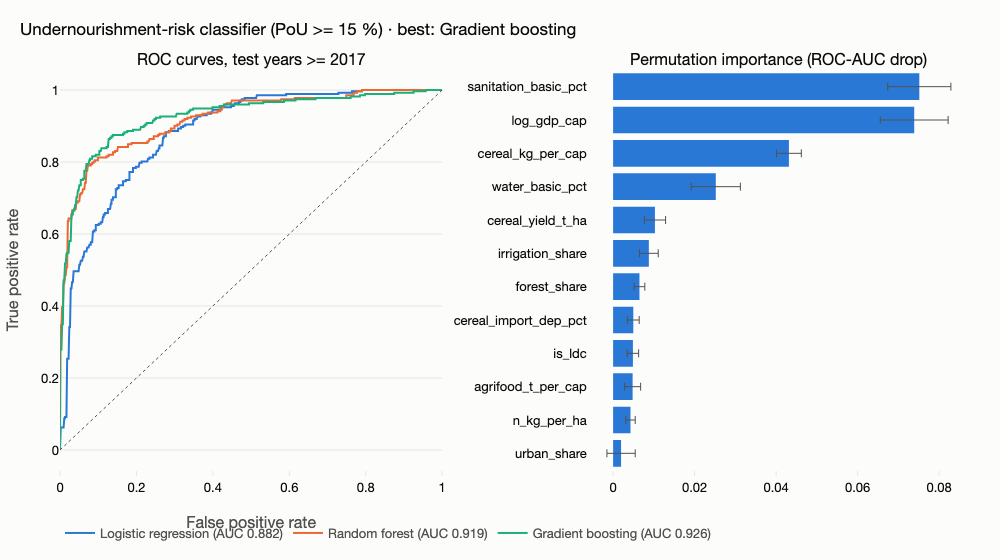

,roc_auc,pr_auc,f1,balanced_accuracy
Logistic regression,0.882,0.774,0.678,0.757
Random forest,0.919,0.885,0.783,0.829
Gradient boosting,0.926,0.893,0.799,0.841


In [43]:
risk_metrics, fig = ml.risk_classifier(panel)
display(fig)
pd.DataFrame({k: {m: v[m] for m in ("roc_auc", "pr_auc", "f1", "balanced_accuracy")} for k, v in risk_metrics["models"].items()}).T.round(3)


In [44]:
scores = pd.read_csv(ROOT / "models" / "risk_scores_latest.csv")
print("positive rate in test years:", round(risk_metrics["positive_rate_test"], 3))
scores.head(15).round(3)


positive rate in test years: 0.337


,area,region,year,risk_score,observed_pou_pct
0,Democratic Republic of the Congo,Africa,2024,1.000,39.5
1,Central African Republic,Africa,2024,1.000,29.8
2,Burundi,Africa,2024,0.999,NaN
3,Nicaragua,Americas,2022,0.998,17.3
4,Congo,Africa,2024,0.990,25.0
5,Papua New Guinea,Oceania,2024,0.989,30.5
6,Madagascar,Africa,2024,0.971,41.8
7,Liberia,Africa,2024,0.964,37.3
8,Mozambique,Africa,2024,0.953,22.3
9,Chad,Africa,2024,0.948,33.6


### 4.3 Food-system typology

k-means on 12 standardised latest-year indicators; k chosen by silhouette; PCA only for display.

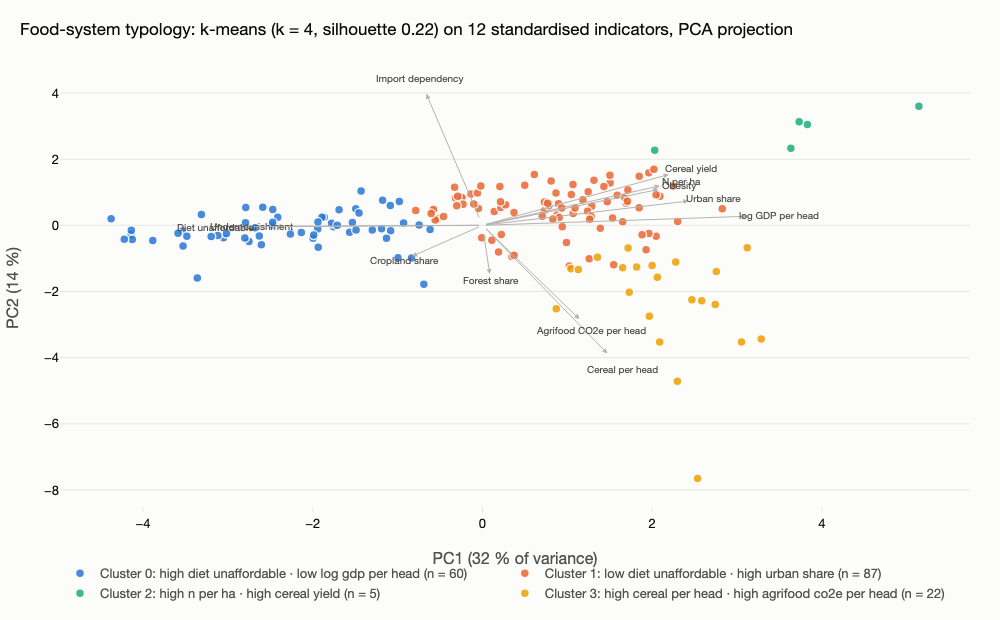

cluster 0 (n = 60): high diet unaffordable · low log gdp per head
    Afghanistan, Angola, Bangladesh, Benin, Burkina Faso, Burundi, Cabo Verde, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo, Côte d'Ivoire …
cluster 1 (n = 87): low diet unaffordable · high urban share
    Albania, Algeria, Antigua and Barbuda, Armenia, Austria, Azerbaijan, Bahamas, Barbados, Belgium, Belize, Bhutan, Bolivia (Plurinational State of), Bosnia and Herzegovina, Botswana …
cluster 2 (n = 5): high n per ha · high cereal yield
    Egypt, Kuwait, Oman, Qatar, United Arab Emirates 
cluster 3 (n = 22): high cereal per head · high agrifood co2e per head
    Argentina, Australia, Belarus, Brazil, Bulgaria, Canada, Denmark, Estonia, France, Guyana, Hungary, Kazakhstan, Latvia, Lithuania …


In [45]:
typology_metrics, fig = ml.typology(panel)
display(fig)
for c in typology_metrics["clusters"]:
    print(f"cluster {c['cluster']} (n = {c['n']}): {c['name']}")
    print("   ", ", ".join(c["members"][:14]), "…" if c["n"] > 14 else "")


### 4.4 Regional cereal projections to 2030

Log-linear trend on 2005–2024 with a 95 % prediction interval from the residual variance.

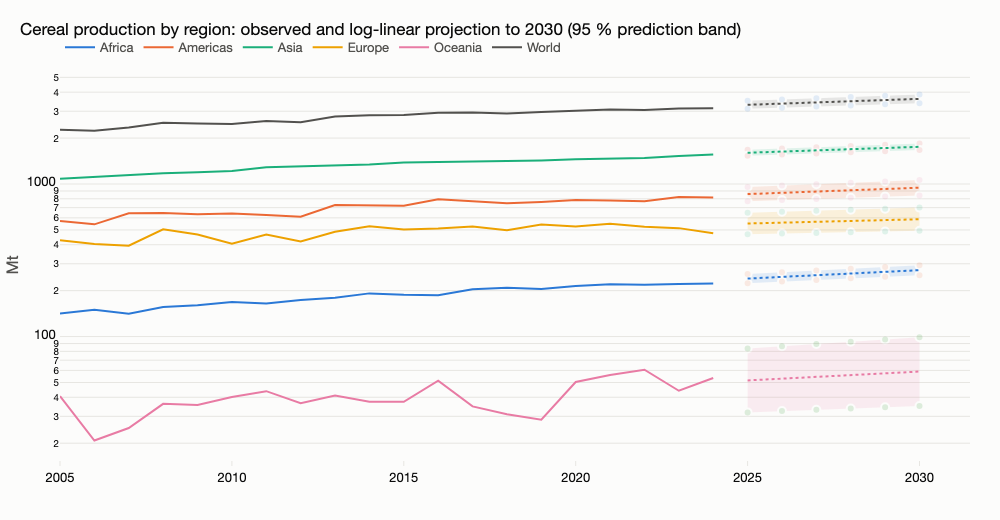

,trend_pct_per_year,projected_2030_mt,latest_mt,latest_year
Africa,2.6,272.5,222.7,2024.0
Americas,1.9,945.6,817.3,2024.0
Asia,1.8,1753.1,1563.9,2024.0
Europe,1.3,587.6,475.8,2024.0
Oceania,2.7,59.0,53.5,2024.0
World,1.8,3615.9,3133.2,2024.0


In [46]:
projection_metrics, fig = ml.projections(con)
display(fig)
pd.DataFrame(projection_metrics["regions"]).T.round(1)


## 5. The dashboard

Everything above is packed into a single static page with filters (regions, country, year range), maps, a free X/Y explorer, the model outputs and a governance tab. It is embedded below; open it full-size at the link.

In [47]:
metrics = json.loads((ROOT / "models" / "metrics.json").read_text())
print("intended use:", metrics["intended_use"])
print()
for lim in metrics["limitations"]:
    print("-", lim)
display(Markdown("**Live dashboard:** https://chidex-coder.github.io/faostat-food-systems-analytics/  \n**Repository:** https://github.com/chidex-coder/faostat-food-systems-analytics"))
IFrame("https://chidex-coder.github.io/faostat-food-systems-analytics/", width="100%", height=820)


intended use: Exploratory screening and planning support on FAO statistics. All models are descriptive, not causal; none should allocate resources or trigger action without human review of the country context.

- Targets are FAO estimates (yield: 45 % official / 53 % estimated-imputed rows; PoU: fully modelled), so the models learn FAO's methodology as much as the world.
- Time-based validation covers 2017-2024 only; structural breaks (conflict, pandemic, price shocks) are under-represented.
- Country-years are not independent samples; reported metrics are optimistic for a never-seen country.
- The risk classifier threshold (PoU >= 15 %) is FAO's 'moderately high' boundary, chosen for interpretability, not optimised for any decision cost.


**Live dashboard:** https://chidex-coder.github.io/faostat-food-systems-analytics/  
**Repository:** https://github.com/chidex-coder/faostat-food-systems-analytics

---
Data © FAO, FAOSTAT bulk downloads, used under the FAO statistical database terms of use. Geography: UN Statistics Division M49.